In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
from rdkit import Chem
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv('Clozapine_dataset.csv')
print(f"Original dataset size: {len(df)}")

c:\Users\Arefeh\anaconda3\envs\pyphi-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original dataset size: 684


In [ ]:
# ============================================================================
# PART 0: LOAD DATA + ONE SHARED SPLIT (used by BOTH models below)
# ============================================================================

all_idx = np.arange(len(df))

# Same split logic/seed you already had (70/15/15), just done ONCE here
idx_train, idx_temp = train_test_split(all_idx, test_size=0.30, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

print(f"Shared split -> Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Shared split -> Train: 478 | Val: 103 | Test: 103


In [3]:
import hashlib
idx_signature = hashlib.md5(np.concatenate([idx_train, idx_val, idx_test]).tobytes()).hexdigest()
print(f"Split signature: {idx_signature}")

Split signature: b89e68489e42613b1923f1ca46aacbd1


In [4]:
# ============================================================================
# PART 1: MORDRED MODEL — YOUR ORIGINAL CODE, split reused instead of re-split
# ============================================================================
act_func_map = {'Tanh': nn.Tanh, 'ReLU': nn.ReLU, 'Sigmoid': nn.Sigmoid, 'ELU': nn.ELU}

def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

def generate_MLP(n_input, hidden_layers, n_out, dropout, act_func):
    if len(hidden_layers) == 0:
        return nn.Sequential(nn.Linear(n_input, n_out), nn.Dropout(dropout))
    sizes = [n_input] + hidden_layers + [n_out]
    layers = []
    for i in range(len(sizes) - 1):
        layers += [nn.Linear(sizes[i], sizes[i + 1]), nn.Dropout(dropout), act_func()]
    return nn.Sequential(*layers[:-1])

from mordred import Calculator
from mordred import (
    SLogP, TopoPSA, HydrogenBond, McGowanVolume,
    Polarizability, Weight, LogS, Lipinski,
    MoeType, CPSA, RotatableBond, RingCount,
    Aromatic, KappaShapeIndex, Constitutional, EState,
    BCUT, VdwVolumeABC, TopologicalIndex, ZagrebIndex,
    ABCIndex, AcidBase, BondCount, CarbonTypes, Chi,
    EccentricConnectivityIndex, TopologicalCharge
)

calc = Calculator([
    SLogP, TopoPSA, HydrogenBond, McGowanVolume,
    Polarizability, Weight, LogS, Lipinski,
    MoeType, CPSA, RotatableBond, RingCount,
    Aromatic, KappaShapeIndex, Constitutional, EState,
    BCUT, VdwVolumeABC, TopologicalIndex, ZagrebIndex,
    ABCIndex, AcidBase, BondCount, CarbonTypes, Chi,
    EccentricConnectivityIndex, TopologicalCharge
], ignore_3D=True)

def smiles_to_mordred(smiles):
    if pd.isna(smiles) or smiles == '':
        return np.zeros(len(calc.descriptors))
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(len(calc.descriptors))
    result = calc(mol)
    values = [float(v) if isinstance(v, (int, float)) else 0.0 for v in result]
    return np.array(values)

fp_solvent1 = np.vstack(df['SMILES_1'].apply(smiles_to_mordred))
fp_solvent2 = np.vstack(df['SMILES_2'].apply(smiles_to_mordred))

x1 = df['comp_1'].values.reshape(-1, 1)
T = df['Temperature (K)'].values.reshape(-1, 1)
X_fp = np.hstack([fp_solvent1, fp_solvent2])
Y = df['LogS'].values.reshape(-1, 1)

print(f"X_fp shape : {X_fp.shape}")
print(f"x1 shape   : {x1.shape}")
print(f"Y shape    : {Y.shape}")

class SolubilityHybridModelV2(nn.Module):
    def __init__(
        self,
        n_fp_features=1362, fp_emb_hidden_layers=None, fp_emb_dropout=0.2,
        fp_emb_actfunc='Tanh', fp_emb_size=64,
        n_comp_features=1, comp_emb_hidden_layers=None, comp_emb_dropout=0.1,
        comp_emb_actfunc='Tanh', comp_emb_size=16,
        physpar_hidden_layers=None, physpar_dropout=0.1, physpar_actfunc='Tanh',
        A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0,
    ):
        super().__init__()
        if fp_emb_hidden_layers is None: fp_emb_hidden_layers = [512, 256, 128]
        if comp_emb_hidden_layers is None: comp_emb_hidden_layers = [16, 16]
        if physpar_hidden_layers is None: physpar_hidden_layers = [32]

        self.A_min, self.A_max = A_min, A_max
        self.B_min, self.B_max = B_min, B_max

        self.fp_branch = generate_MLP(n_fp_features, fp_emb_hidden_layers, fp_emb_size,
                                       fp_emb_dropout, act_func_map[fp_emb_actfunc])
        self.comp_branch = generate_MLP(n_comp_features, comp_emb_hidden_layers, comp_emb_size,
                                         comp_emb_dropout, act_func_map[comp_emb_actfunc])
        fusion_size = fp_emb_size + comp_emb_size
        self.physpar_head = generate_MLP(fusion_size, physpar_hidden_layers, 2,
                                          physpar_dropout, act_func_map[physpar_actfunc])
        self.apply(initialize_weights)

    def get_AB(self, X_fp, x1):
        fp_emb = self.fp_branch(X_fp)
        comp_emb = self.comp_branch(x1)
        fused = torch.cat([fp_emb, comp_emb], dim=1)
        raw = self.physpar_head(fused)
        A = torch.sigmoid(raw[:, 0:1]) * (self.A_max - self.A_min) + self.A_min
        B = torch.sigmoid(raw[:, 1:2]) * (self.B_max - self.B_min) + self.B_min
        return A, B

    def forward(self, X_fp, x1, T):
        A, B = self.get_AB(X_fp, x1)
        return A + B / T

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def reset_parameters(self):
        self.apply(initialize_weights)



X_fp shape : (684, 1362)
x1 shape   : (684, 1)
Y shape    : (684, 1)


In [6]:
# ── Scaling (fit on full data, same as your original) ──────────────────────
scaler_fp = StandardScaler()
X_fp_scaled = scaler_fp.fit_transform(X_fp)

scaler_comp = StandardScaler()
x1_scaled = scaler_comp.fit_transform(x1)

X_fp_train, x1_train, T_train, Y_train = X_fp_scaled[idx_train], x1_scaled[idx_train], T[idx_train], Y[idx_train]
X_fp_val,   x1_val,   T_val,   Y_val   = X_fp_scaled[idx_val],   x1_scaled[idx_val],   T[idx_val],   Y[idx_val]
X_fp_test,  x1_test,  T_test,  Y_test  = X_fp_scaled[idx_test],  x1_scaled[idx_test],  T[idx_test],  Y[idx_test]

print(f"Train: {len(X_fp_train)} | Val: {len(X_fp_val)} | Test: {len(X_fp_test)}")

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(to_t, [X_fp_train, x1_train, T_train, Y_train])
X_fp_val_t,   x1_val_t,   T_val_t,   Y_val_t   = map(to_t, [X_fp_val,   x1_val,   T_val,   Y_val])
X_fp_test_t,  x1_test_t,  T_test_t,  Y_test_t  = map(to_t, [X_fp_test,  x1_test,  T_test,  Y_test])

train_ds = TensorDataset(X_fp_train_t, x1_train_t, T_train_t, Y_train_t)
val_ds   = TensorDataset(X_fp_val_t,   x1_val_t,   T_val_t,   Y_val_t)
test_ds  = TensorDataset(X_fp_test_t,  x1_test_t,  T_test_t,  Y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=len(val_ds),   shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=len(test_ds),  shuffle=False)

mordred_model = SolubilityHybridModelV2(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    physpar_hidden_layers=[32], physpar_dropout=0.1, physpar_actfunc='Tanh',
    A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0,
)
print(f"Total trainable parameters: {mordred_model.count_parameters()}")

optimizer = torch.optim.Adam(mordred_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss, patience_counter, best_weights = float('inf'), 0, None
train_losses, val_losses = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader:
        optimizer.zero_grad()
        Y_pred = mordred_model(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds)

    mordred_model.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader:
            epoch_val_loss = criterion(mordred_model(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_weights = {k: v.clone() for k, v in mordred_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val_loss:.4f}")

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    return r2, rmse, mae

mordred_model.eval()
with torch.no_grad():
    Y_pred_train_mordred = mordred_model(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val_mordred   = mordred_model(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test_mordred  = mordred_model(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np, Y_val_np, Y_test_np = Y_train_t.numpy().flatten(), Y_val_t.numpy().flatten(), Y_test_t.numpy().flatten()

r2_train_m, rmse_train_m, mae_train_m = get_metrics(Y_train_np, Y_pred_train_mordred)
r2_val_m, rmse_val_m, mae_val_m = get_metrics(Y_val_np, Y_pred_val_mordred)
r2_test_m, rmse_test_m, mae_test_m = get_metrics(Y_test_np, Y_pred_test_mordred)

print(f"\n[Mordred] Train | R²={r2_train_m:.4f} RMSE={rmse_train_m:.4f} MAE={mae_train_m:.4f}")
print(f"[Mordred] Val   | R²={r2_val_m:.4f} RMSE={rmse_val_m:.4f} MAE={mae_val_m:.4f}")
print(f"[Mordred] Test  | R²={r2_test_m:.4f} RMSE={rmse_test_m:.4f} MAE={mae_test_m:.4f}")

Train: 478 | Val: 103 | Test: 103
Total trainable parameters: 873570
Epoch   50 | Train: 0.2274 | Val: 0.0885
Epoch  100 | Train: 0.1637 | Val: 0.0320
Epoch  150 | Train: 0.1389 | Val: 0.0216
Epoch  200 | Train: 0.1100 | Val: 0.0242
Epoch  250 | Train: 0.1211 | Val: 0.0150
Epoch  300 | Train: 0.1075 | Val: 0.0124
Epoch  350 | Train: 0.0977 | Val: 0.0169
Epoch  400 | Train: 0.1103 | Val: 0.0111
Early stopping at epoch 408

Best val loss: 0.0074

[Mordred] Train | R²=0.9900 RMSE=0.0926 MAE=0.0688
[Mordred] Val   | R²=0.9901 RMSE=0.0858 MAE=0.0687
[Mordred] Test  | R²=0.9912 RMSE=0.0922 MAE=0.0755


In [16]:
import pickle

# ── Save model weights + scalers + architecture config together ────────────
torch.save({
    'model_state_dict': mordred_model.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'physpar_hidden_layers': [32], 'physpar_dropout': 0.1, 'physpar_actfunc': 'Tanh',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'mordred_random_model.pt')

with open('mordred_random_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp, 'scaler_comp': scaler_comp}, f)

print("Saved model to 'mordred_random_model.pt' and scalers to 'mordred_random_scalers.pkl'")

Saved model to 'mordred_random_model.pt' and scalers to 'mordred_random_scalers.pkl'


In [6]:
# ============================================================================
# Load the model and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load model + scalers (no training required) ─────────────────────────────
checkpoint = torch.load('mordred_random_model.pt')

mordred_model = SolubilityHybridModelV2(**checkpoint['model_config'])
mordred_model.load_state_dict(checkpoint['model_state_dict'])
mordred_model.eval()

with open('mordred_random_scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)
scaler_fp = scalers['scaler_fp']
scaler_comp = scalers['scaler_comp']

print("Loaded mordred_random_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_random_model and scalers — ready for inference/plotting, no training needed.


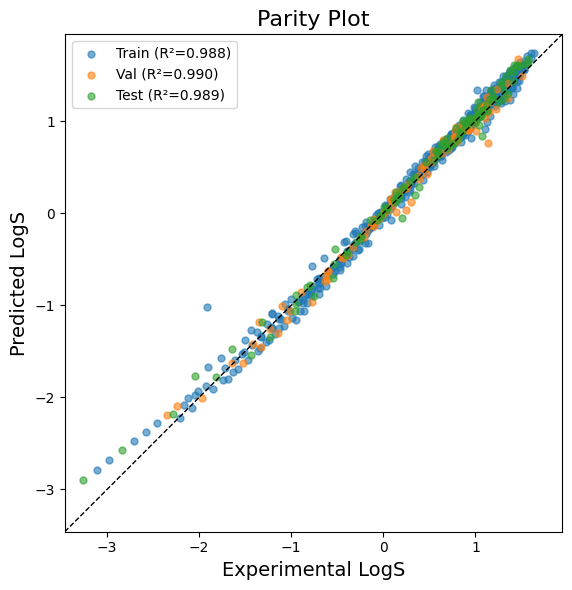

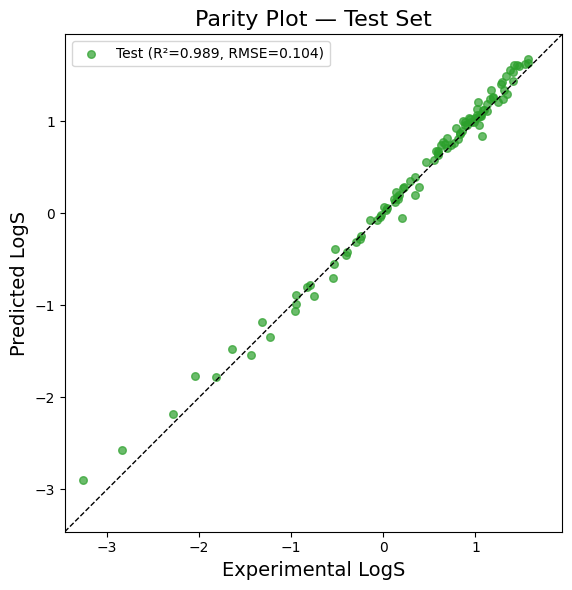

In [10]:
import matplotlib.pyplot as plt

# ── Rebuild scaled features using the LOADED scalers (transform only) ──────
X_fp_scaled = scaler_fp.transform(X_fp)
x1_scaled   = scaler_comp.transform(x1)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(to_t, [X_fp_scaled[idx_train], x1_scaled[idx_train], T[idx_train], Y[idx_train]])
X_fp_val_t,   x1_val_t,   T_val_t,   Y_val_t   = map(to_t, [X_fp_scaled[idx_val],   x1_scaled[idx_val],   T[idx_val],   Y[idx_val]])
X_fp_test_t,  x1_test_t,  T_test_t,  Y_test_t  = map(to_t, [X_fp_scaled[idx_test],  x1_scaled[idx_test],  T[idx_test],  Y[idx_test]])

# ── Get predictions ──────────────────────────────────────────────────────
mordred_model.eval()
with torch.no_grad():
    Y_pred_train = mordred_model(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_model(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_model(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot — Test Set', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [5]:
# ============================================================================
# PART 2: CHEMBERTA MODEL — YOUR ORIGINAL CODE, split reused instead of random_split
# ============================================================================
class FineTunedChemBERTa(nn.Module):
    def __init__(self, model_name, mix_emb_hidden_layers, mix_emb_dropout,
                 mix_emb_actfunc, mix_emb_size, physpar_hidden_layers,
                 physpar_dropout, physpar_actfunc,
                 A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0):
        super().__init__()
        print(f"Loading ChemBERTa model: {model_name}")
        self.chemberta = AutoModel.from_pretrained(model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.mix_embedding = generate_MLP(
            n_input=1536, hidden_layers=mix_emb_hidden_layers, n_out=mix_emb_size,
            dropout=mix_emb_dropout, act_func=act_func_map[mix_emb_actfunc]
        )
        self.composition_encoder = generate_MLP(
            n_input=1, hidden_layers=[16, 8], n_out=16, dropout=0.1, act_func=nn.ReLU
        )
        self.physpar_model = generate_MLP(
            n_input=mix_emb_size + 16, hidden_layers=physpar_hidden_layers, n_out=2,
            dropout=physpar_dropout, act_func=act_func_map[physpar_actfunc]
        )
        self.A_min, self.A_max, self.B_min, self.B_max = A_min, A_max, B_min, B_max
        self.apply(initialize_weights)

    def encode_smiles(self, smiles_list):
        tokens = self.tokenizer(
            smiles_list, return_tensors="pt", padding=True, truncation=True,
            max_length=256, add_special_tokens=True
        ).to(next(self.chemberta.parameters()).device)
        outputs = self.chemberta(**tokens)
        attention_mask = tokens['attention_mask']
        hidden_states = outputs.last_hidden_state
        masked_hidden = hidden_states * attention_mask.unsqueeze(-1)
        embeddings = masked_hidden.sum(dim=1) / attention_mask.sum(dim=1).unsqueeze(-1)
        return embeddings

    def forward(self, smiles1_list, smiles2_list, comp1_list, T_list):
        fp1 = self.encode_smiles(smiles1_list)
        fp2 = self.encode_smiles(smiles2_list)
        fp_concat = torch.cat([fp1, fp2], dim=1)
        mix_e = self.mix_embedding(fp_concat)
        comp1 = comp1_list.reshape(-1, 1)
        comp_encoded = self.composition_encoder(comp1)
        combined = torch.cat([mix_e, comp_encoded], dim=1)
        phys_pars = self.physpar_model(combined)
        A = torch.sigmoid(phys_pars[:, 0]).reshape(-1, 1) * (self.A_max - self.A_min) + self.A_min
        B = torch.sigmoid(phys_pars[:, 1]).reshape(-1, 1) * (self.B_max - self.B_min) + self.B_min
        T = T_list.reshape(-1, 1)
        return A + B / T

    def unfreeze_chemberta(self, unfreeze_layers=-1):
        if unfreeze_layers == -1:
            for param in self.chemberta.parameters():
                param.requires_grad = True
            print("Unfroze all ChemBERTa layers")
        else:
            layers = list(self.chemberta.parameters())
            if unfreeze_layers > 0:
                for param in layers[-unfreeze_layers:]:
                    param.requires_grad = True
                print(f"Unfroze last {unfreeze_layers} layers of ChemBERTa")

    def freeze_chemberta(self):
        for param in self.chemberta.parameters():
            param.requires_grad = False
        print("Froze all ChemBERTa layers")

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

class SolubilityDataset(Dataset):
    def __init__(self, df):
        self.original_indices = df.index.values
        self.smiles1 = df['SMILES_1'].values
        self.smiles2 = df['SMILES_2'].values
        self.comp1 = df['comp_1'].values.astype(np.float32)
        self.T = df['Temperature (K)'].values.astype(np.float32)
        self.y = df['LogS'].values.astype(np.float32)

        mask = ~(pd.isna(self.smiles1) | pd.isna(self.smiles2) |
                 pd.isna(self.comp1) | pd.isna(self.T) | pd.isna(self.y))

        self.original_indices = self.original_indices[mask]
        self.smiles1 = self.smiles1[mask]
        self.smiles2 = self.smiles2[mask]
        self.comp1 = self.comp1[mask]
        self.T = self.T[mask]
        self.y = self.y[mask]

        print(f"Dataset size: {len(self.y)} samples")

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            'smiles1': self.smiles1[idx], 'smiles2': self.smiles2[idx],
            'comp1': torch.tensor(self.comp1[idx], dtype=torch.float32),
            'T': torch.tensor(self.T[idx], dtype=torch.float32),
            'y': torch.tensor(self.y[idx], dtype=torch.float32),
            'original_idx': self.original_indices[idx]
        }

def collate_fn(batch):
    smiles1 = [item['smiles1'] for item in batch]
    smiles2 = [item['smiles2'] for item in batch]
    comp1 = torch.stack([item['comp1'] for item in batch])
    T = torch.stack([item['T'] for item in batch])
    y = torch.stack([item['y'] for item in batch])
    original_idx = [item['original_idx'] for item in batch]
    return smiles1, smiles2, comp1, T, y, original_idx

def train_model(model, train_loader, val_loader, epochs, lr, device,
                stage_name="", unfreeze_after_epochs=None,
                best_val_loss=float('inf'), best_weights=None):
    if unfreeze_after_epochs is None:
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr * 0.1)

    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

    train_losses, val_losses, val_r2_scores = [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for smiles1, smiles2, comp1, T, y, original_idx in train_loader:
            comp1, T, y = comp1.to(device), T.to(device), y.to(device)
            optimizer.zero_grad()
            predictions = model(smiles1, smiles2, comp1, T)
            loss = criterion(predictions.squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for smiles1, smiles2, comp1, T, y, original_idx in val_loader:
                comp1, T, y = comp1.to(device), T.to(device), y.to(device)
                predictions = model(smiles1, smiles2, comp1, T)
                loss = criterion(predictions.squeeze(), y)
                val_loss += loss.item()
                all_preds.extend(predictions.squeeze().cpu().numpy())
                all_targets.extend(y.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        all_preds, all_targets = np.array(all_preds), np.array(all_targets)
        ss_res = np.sum((all_targets - all_preds) ** 2)
        ss_tot = np.sum((all_targets - np.mean(all_targets)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        val_r2_scores.append(r2)

        scheduler.step(avg_val_loss)

        # ── Best-checkpoint tracking (mirrors the Mordred model's logic) ──
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"{stage_name} Epoch {epoch+1}/{epochs}: "
                  f"Train Loss: {avg_train_loss:.4f}, "
                  f"Val Loss: {avg_val_loss:.4f}, "
                  f"Val R²: {r2:.4f}, "
                  f"Best Val: {best_val_loss:.4f}, "
                  f"LR: {current_lr:.6f}")
            print(f"  Pred range: [{all_preds.min():.2f}, {all_preds.max():.2f}], "
                  f"Target range: [{all_targets.min():.2f}, {all_targets.max():.2f}]")

        if unfreeze_after_epochs and epoch + 1 == unfreeze_after_epochs:
            print(f"\n*** Unfreezing ChemBERTa layers for stage {stage_name} ***")
            model.unfreeze_chemberta(unfreeze_layers=4)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr * 0.1)

    return train_losses, val_losses, val_r2_scores, best_val_loss, best_weights

In [17]:
# ── Dataset + SPLIT: reuse shared idx_train/idx_val/idx_test via Subset ────
# (df here has no NaNs across the required columns, so dataset row order
#  matches df row order 1:1 — Subset with the shared indices gives the
#  exact same rows used by the Mordred model above)
chemberta_dataset = SolubilityDataset(df)

chem_train_dataset = Subset(chemberta_dataset, idx_train)
chem_val_dataset   = Subset(chemberta_dataset, idx_val)
chem_test_dataset  = Subset(chemberta_dataset, idx_test)

batch_size = 32
chem_train_loader = DataLoader(chem_train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
chem_val_loader   = DataLoader(chem_val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
chem_test_loader  = DataLoader(chem_test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"[ChemBERTa] Train size: {len(chem_train_dataset)}, Val size: {len(chem_val_dataset)}, Test size: {len(chem_test_dataset)}")

chemberta_model = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256],
    mix_emb_dropout=0.3,
    mix_emb_actfunc='ReLU',
    mix_emb_size=128,
    physpar_hidden_layers=[64, 32],
    physpar_dropout=0.2,
    physpar_actfunc='ReLU'
).to(DEVICE)
print(f"Total trainable parameters: {chemberta_model.count_parameters():,}")

print("\n" + "="*60)
print("STAGE 1: Training MLP heads only (ChemBERTa frozen)")
print("="*60)
chemberta_model.freeze_chemberta()
train_losses_1, val_losses_1, r2_scores_1, best_val_loss_c, best_weights_c = train_model(
    chemberta_model, chem_train_loader, chem_val_loader, epochs=50, lr=0.001,
    device=DEVICE, stage_name="Stage 1"
)

print("\n" + "="*60)
print("STAGE 2: Fine-tuning ChemBERTa (lower learning rate)")
print("="*60)
chemberta_model.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2, val_losses_2, r2_scores_2, best_val_loss_c, best_weights_c = train_model(
    chemberta_model, chem_train_loader, chem_val_loader, epochs=30, lr=0.0001,
    device=DEVICE, stage_name="Stage 2",
    best_val_loss=best_val_loss_c, best_weights=best_weights_c   # carry over from Stage 1
)

# ── Load the best checkpoint across BOTH stages before evaluating ──
chemberta_model.load_state_dict(best_weights_c)
print(f"\nLoaded best ChemBERTa checkpoint (val loss = {best_val_loss_c:.4f})")

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET (ChemBERTa)")
print("="*60)
chemberta_model.eval()
test_preds_c, test_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_test_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_model(smiles1, smiles2, comp1, T)
        test_preds_c.extend(predictions.squeeze().cpu().numpy())
        test_targets_c.extend(y.numpy())

test_preds_c, test_targets_c = np.array(test_preds_c), np.array(test_targets_c)
r2_c, rmse_c, mae_c = get_metrics(test_targets_c, test_preds_c)
print(f"[ChemBERTa] Test | R²={r2_c:.4f} RMSE={rmse_c:.4f} MAE={mae_c:.4f}")

Dataset size: 684 samples
[ChemBERTa] Train size: 478, Val size: 103, Test size: 103
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Total trainable parameters: 45,066,842

STAGE 1: Training MLP heads only (ChemBERTa frozen)
Froze all ChemBERTa layers
Stage 1 Epoch 10/50: Train Loss: 3.5889, Val Loss: 1.0076, Val R²: -0.5082, Best Val: 0.8812, LR: 0.001000
  Pred range: [0.70, 1.00], Target range: [-2.35, 1.50]
Stage 1 Epoch 20/50: Train Loss: 0.6525, Val Loss: 0.3657, Val R²: 0.4958, Best Val: 0.3031, LR: 0.001000
  Pred range: [-0.85, 1.04], Target range: [-2.35, 1.50]
Stage 1 Epoch 30/50: Train Loss: 0.4850, Val Loss: 0.1862, Val R²: 0.7423, Best Val: 0.1862, LR: 0.001000
  Pred range: [-1.38, 1.21], Target range: [-2.35, 1.50]
Stage 1 Epoch 40/50: Train Loss: 0.3317, Val Loss: 0.1584, Val R²: 0.7890, Best Val: 0.1058, LR: 0.001000
  Pred range: [-1.57, 1.08], Target range: [-2.35, 1.50]
Stage 1 Epoch 50/50: Train Loss: 0.2940, Val Loss: 0.0944, Val R²: 0.8800, Best Val: 0.0

In [20]:
import pickle

# ── Save ChemBERTa (random split) model + config ────────────────────────────
torch.save({
    'model_state_dict': chemberta_model.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'physpar_hidden_layers': [64, 32], 'physpar_dropout': 0.2, 'physpar_actfunc': 'ReLU',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'chemberta_random_model.pt')

print("Saved ChemBERTa (random split) model to 'chemberta_random_model.pt'")

Saved ChemBERTa (random split) model to 'chemberta_random_model.pt'


In [ ]:
import pickle

# ── Load ChemBERTa (random split) model — no training required ─────────────
checkpoint_chemberta_random = torch.load('chemberta_random_model.pt', map_location=DEVICE)

chemberta_model_random = FineTunedChemBERTa(**checkpoint_chemberta_random['model_config']).to(DEVICE)
chemberta_model_random.load_state_dict(checkpoint_chemberta_random['model_state_dict'])
chemberta_model_random.eval()

print("Loaded chemberta_model_random — ready for inference/plotting, no training needed.")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_model_random — ready for inference/plotting, no training needed.


Dataset size: 684 samples


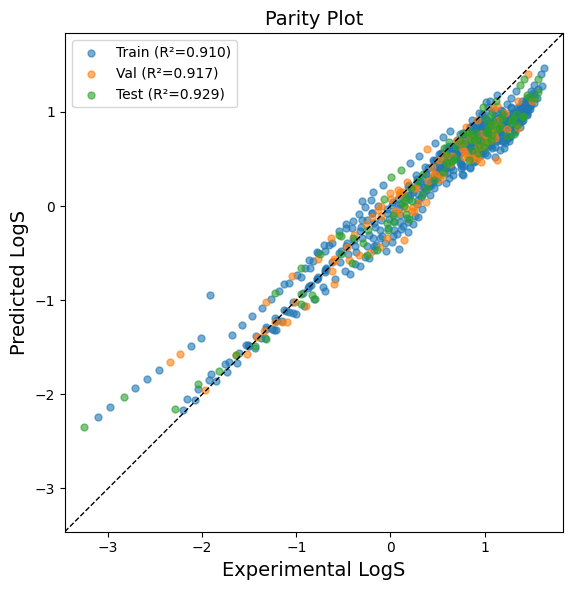

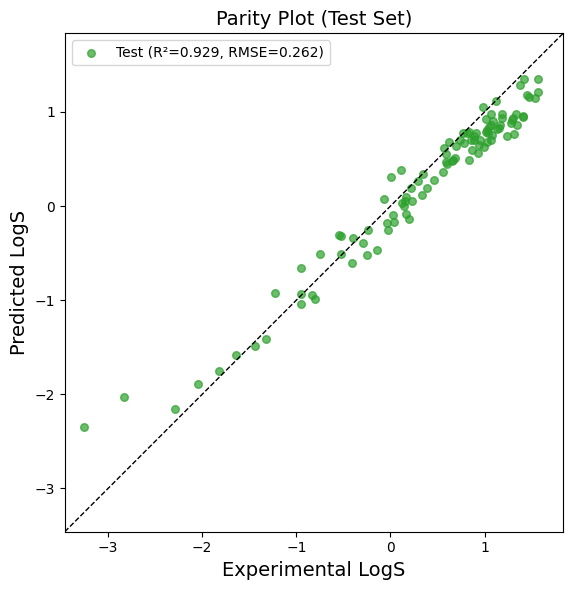


[ChemBERTa] Train | R²=0.9098 RMSE=0.2785, MAE=0.2259
[ChemBERTa] Val   | R²=0.9168 RMSE=0.2492, MAE=0.1960
[ChemBERTa] Test  | R²=0.9291 RMSE=0.2624, MAE=0.2111


In [18]:
# ============================================================================
# Plotting for ChemBERTa Model (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# ── We need the dataset to get the splits ──────────────────────────────────
# Since ChemBERTa uses the dataset with Subset, we need to create it
# Note: For ChemBERTa, we don't need to scale inputs (it uses tokenizer for SMILES)
# but we need the dataset to access the data

# Recreate the dataset (same as in training)
chemberta_dataset = SolubilityDataset(df)  # Make sure SolubilityDataset class is defined

# Get the subsets using the same indices
chem_train_dataset = Subset(chemberta_dataset, idx_train)
chem_val_dataset   = Subset(chemberta_dataset, idx_val)
chem_test_dataset  = Subset(chemberta_dataset, idx_test)

# Create data loaders (no shuffling needed for predictions)
batch_size = 32
chem_train_loader = DataLoader(chem_train_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
chem_val_loader   = DataLoader(chem_val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
chem_test_loader  = DataLoader(chem_test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# ── Get predictions for all sets ──────────────────────────────────────────
chemberta_model_random.eval()

# Train set predictions
train_preds_c, train_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_train_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_model_random(smiles1, smiles2, comp1, T)
        train_preds_c.extend(predictions.squeeze().cpu().numpy())
        train_targets_c.extend(y.numpy())

# Validation set predictions
val_preds_c, val_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_val_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_model_random(smiles1, smiles2, comp1, T)
        val_preds_c.extend(predictions.squeeze().cpu().numpy())
        val_targets_c.extend(y.numpy())

# Test set predictions
test_preds_c, test_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_test_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_model_random(smiles1, smiles2, comp1, T)
        test_preds_c.extend(predictions.squeeze().cpu().numpy())
        test_targets_c.extend(y.numpy())

# Convert to numpy arrays
train_preds_c = np.array(train_preds_c)
train_targets_c = np.array(train_targets_c)
val_preds_c = np.array(val_preds_c)
val_targets_c = np.array(val_targets_c)
test_preds_c = np.array(test_preds_c)
test_targets_c = np.array(test_targets_c)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets_c, train_preds_c)
r2_val,   rmse_val   = get_metrics(val_targets_c,   val_preds_c)
r2_test,  rmse_test  = get_metrics(test_targets_c,  test_preds_c)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets_c, val_targets_c, test_targets_c])
all_pred = np.concatenate([train_preds_c, val_preds_c, test_preds_c])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets_c, train_preds_c, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets_c,   val_preds_c,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets_c,  test_preds_c,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets_c, test_preds_c, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets_c - train_preds_c)):.4f}")
print(f"[ChemBERTa] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets_c - val_preds_c)):.4f}")
print(f"[ChemBERTa] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets_c - test_preds_c)):.4f}")


COMPARISON — SAME TRAIN/TEST SPLIT FOR BOTH MODELS
Model       Set             R²      RMSE       MAE
ChemBERTa   Train       0.9098    0.2785    0.2259
ChemBERTa   Test        0.9291    0.2624    0.2111
Mordred     Train       0.9883    0.1001    0.0758
Mordred     Test        0.9888    0.1041    0.0794


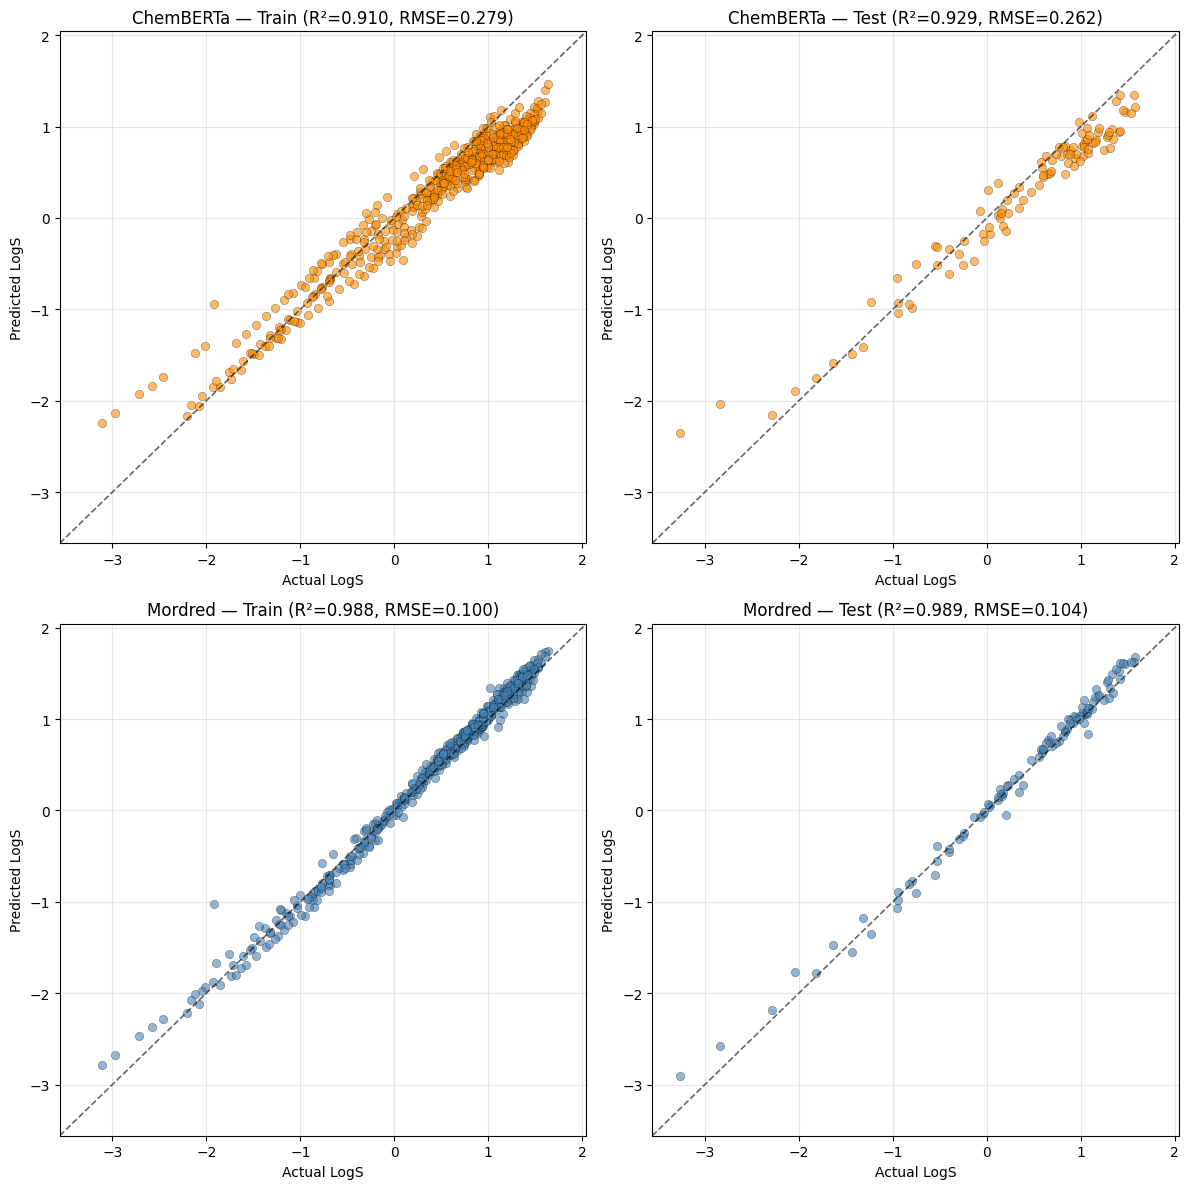

In [22]:
# ============================================================================
# PART 3: SIDE-BY-SIDE COMPARISON — 2x2 GRID (rows: model, cols: train/test)
# ============================================================================

# ── Get ChemBERTa predictions on the TRAINING set (test set already computed above) ──
chemberta_model.eval()
train_preds_c, train_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_train_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_model(smiles1, smiles2, comp1, T)
        train_preds_c.extend(predictions.squeeze().cpu().numpy())
        train_targets_c.extend(y.numpy())

train_preds_c, train_targets_c = np.array(train_preds_c), np.array(train_targets_c)
r2_train_c, rmse_train_c, mae_train_c = get_metrics(train_targets_c, train_preds_c)

print("\n" + "="*60)
print("COMPARISON — SAME TRAIN/TEST SPLIT FOR BOTH MODELS")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c:>10.4f}{rmse_train_c:>10.4f}{mae_train_c:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c:>10.4f}{rmse_c:>10.4f}{mae_c:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m:>10.4f}{rmse_train_m:>10.4f}{mae_train_m:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m:>10.4f}{rmse_test_m:>10.4f}{mae_test_m:>10.4f}")

# ── 2x2 grid: row 0 = ChemBERTa, row 1 = Mordred | col 0 = Train, col 1 = Test ──
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals = np.concatenate([train_targets_c, train_preds_c, test_targets_c, test_preds_c,
                           Y_train_np, Y_pred_train_mordred, Y_test_np, Y_pred_test_mordred])
lims = [all_vals.min() - 0.3, all_vals.max() + 0.3]

plot_specs = [
    # (row, col, y_true, y_pred, color, model_name, set_name, r2, rmse)
    (0, 0, train_targets_c, train_preds_c, 'darkorange', 'ChemBERTa', 'Train', r2_train_c, rmse_train_c),
    (0, 1, test_targets_c,  test_preds_c,  'darkorange', 'ChemBERTa', 'Test',  r2_c,        rmse_c),
    (1, 0, Y_train_np,      Y_pred_train_mordred, 'steelblue', 'Mordred', 'Train', r2_train_m, rmse_train_m),
    (1, 1, Y_test_np,       Y_pred_test_mordred,  'steelblue', 'Mordred', 'Test',  r2_test_m,  rmse_test_m),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual LogS')
    ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2.png', dpi=150)
plt.show()

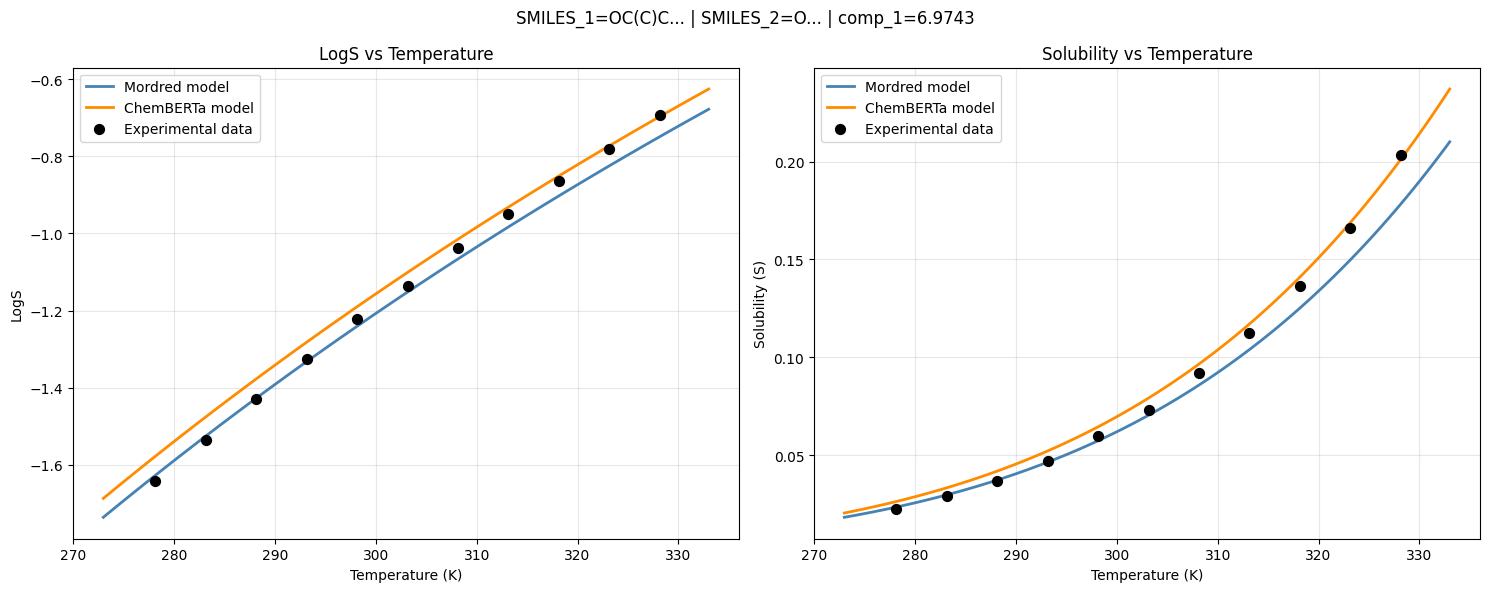

In [ ]:
# ============================================================================
# PART 4: SOLUBILITY and LogS vs TEMPERATURE FOR A CHOSEN SOLVENT COMBINATION
# ============================================================================

def list_available_combinations():
    """Helper: see which SMILES pairs + comp_1 values actually exist in the dataset."""
    combos = df[['SMILES_1', 'SMILES_2', 'comp_1']].drop_duplicates().reset_index(drop=True)
    print(f"{len(combos)} unique solvent/composition combinations in the dataset:")
    print(combos.to_string())
    return combos

def plot_logs_and_solubility_vs_temperature(smiles_1, smiles_2, comp_1,
                                             T_min=270, T_max=330, n_points=100,
                                             models=('mordred', 'chemberta'),
                                             show_data=True, comp_tol=0.02):
    """
    Plot BOTH LogS vs Temperature (left) and Solubility=10^LogS vs Temperature (right),
    side by side, for a fixed solvent pair + composition.
    Only T is swept; SMILES_1, SMILES_2, comp_1 are held fixed.
    """
    T_range = np.linspace(T_min, T_max, n_points)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    ax_logs, ax_solub = axes[0], axes[1]

    # ── Mordred model prediction curve ──────────────────────────────────────
    if 'mordred' in models:
        fp1 = smiles_to_mordred(smiles_1)
        fp2 = smiles_to_mordred(smiles_2)
        X_fp_combo = np.hstack([fp1, fp2]).reshape(1, -1)
        X_fp_combo_scaled = scaler_fp.transform(X_fp_combo)
        x1_combo_scaled = scaler_comp.transform(np.array([[comp_1]]))

        X_fp_rep = np.repeat(X_fp_combo_scaled, n_points, axis=0)
        x1_rep = np.repeat(x1_combo_scaled, n_points, axis=0)
        T_col = T_range.reshape(-1, 1)

        mordred_model.eval()
        with torch.no_grad():
            preds_m_logs = mordred_model(to_t(X_fp_rep), to_t(x1_rep), to_t(T_col)).numpy().flatten()
        preds_m = 10 ** preds_m_logs

        ax_logs.plot(T_range, preds_m_logs, color='steelblue', lw=2, label='Mordred model')
        ax_solub.plot(T_range, preds_m, color='steelblue', lw=2, label='Mordred model')

    # ── ChemBERTa model prediction curve ────────────────────────────────────
    if 'chemberta' in models:
        chemberta_model.eval()
        smiles1_list = [smiles_1] * n_points
        smiles2_list = [smiles_2] * n_points
        comp1_t = torch.tensor([comp_1] * n_points, dtype=torch.float32).to(DEVICE)
        T_t = torch.tensor(T_range, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            preds_c_logs = chemberta_model(smiles1_list, smiles2_list, comp1_t, T_t).cpu().numpy().flatten()
        preds_c = 10 ** preds_c_logs

        ax_logs.plot(T_range, preds_c_logs, color='darkorange', lw=2, label='ChemBERTa model')
        ax_solub.plot(T_range, preds_c, color='darkorange', lw=2, label='ChemBERTa model')

    # ── Overlay real experimental points near this combo, if any ───────────
    if show_data:
        mask = (
            (df['SMILES_1'] == smiles_1) &
            (df['SMILES_2'] == smiles_2) &
            (np.isclose(df['comp_1'], comp_1, atol=comp_tol))
        )
        subset = df[mask]
        if len(subset) > 0:
            ax_logs.scatter(subset['Temperature (K)'], subset['LogS'],
                             color='black', zorder=5, s=50, label='Experimental data')
            ax_solub.scatter(subset['Temperature (K)'], 10 ** subset['LogS'],
                              color='black', zorder=5, s=50, label='Experimental data')
        else:
            print(f"No experimental rows found matching comp_1≈{comp_1} (tol={comp_tol}) for this pair.")

    ax_logs.set_xlabel('Temperature (K)')
    ax_logs.set_ylabel('LogS')
    ax_logs.set_title('LogS vs Temperature')
    ax_logs.legend()
    ax_logs.grid(alpha=0.3)

    ax_solub.set_xlabel('Temperature (K)')
    ax_solub.set_ylabel('Solubility (S)')
    ax_solub.set_title('Solubility vs Temperature')
    ax_solub.legend()
    ax_solub.grid(alpha=0.3)

    fig.suptitle(f'SMILES_1={smiles_1[:25]}... | SMILES_2={smiles_2[:25]}... | comp_1={comp_1}', fontsize=12)
    plt.tight_layout()
    plt.show()


# ── Example usage ────────────────────────────────────────────────────────────
plot_logs_and_solubility_vs_temperature(
    smiles_1="OC(C)C",
    smiles_2="O",
    comp_1=6.9743,
    T_min=273, T_max=333,
    models=('mordred', 'chemberta')
)

In [30]:
# ============================================================================
# min TEMPERATURE-BASED SPLIT (separate from the random split — different names)
# Holds out T = 278.15 K and T = 283.15 K entirely for test.
# ============================================================================
HOLDOUT_TEMPS = [278.15, 283.15]

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)

idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values

# Carve a validation set out of the remaining (non-holdout) rows
idx_temp_train, idx_temp_val = train_test_split(
    idx_temp_remain, test_size=0.15, random_state=42
)

print(f"Temperature split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

Temperature split -> Train: 528 | Val: 94 | Test: 62
Test temperatures: [278.15, 283.15]


In [31]:
# ============================================================================
# STAGE 2: MORDRED MODEL — min TEMPERATURE-BASED SPLIT 
# ============================================================================

T = df['Temperature (K)'].values.reshape(-1, 1)
# ── Scale features, fit ONLY on the temperature-split training rows ────────
scaler_fp_temp = StandardScaler().fit(X_fp[idx_temp_train])
scaler_comp_temp = StandardScaler().fit(x1[idx_temp_train])

X_fp_train_temp = scaler_fp_temp.transform(X_fp[idx_temp_train])
X_fp_val_temp   = scaler_fp_temp.transform(X_fp[idx_temp_val])
X_fp_test_temp  = scaler_fp_temp.transform(X_fp[idx_temp_test])

x1_train_temp = scaler_comp_temp.transform(x1[idx_temp_train])
x1_val_temp   = scaler_comp_temp.transform(x1[idx_temp_val])
x1_test_temp  = scaler_comp_temp.transform(x1[idx_temp_test])

T_train_temp, T_val_temp, T_test_temp = T[idx_temp_train], T[idx_temp_val], T[idx_temp_test]
Y_train_temp, Y_val_temp, Y_test_temp = Y[idx_temp_train], Y[idx_temp_val], Y[idx_temp_test]

print(f"[Temp split/Mordred] Train: {len(X_fp_train_temp)} | Val: {len(X_fp_val_temp)} | Test: {len(X_fp_test_temp)}")

X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t = map(
    to_t, [X_fp_train_temp, x1_train_temp, T_train_temp, Y_train_temp]
)
X_fp_val_temp_t, x1_val_temp_t, T_val_temp_t, Y_val_temp_t = map(
    to_t, [X_fp_val_temp, x1_val_temp, T_val_temp, Y_val_temp]
)
X_fp_test_temp_t, x1_test_temp_t, T_test_temp_t, Y_test_temp_t = map(
    to_t, [X_fp_test_temp, x1_test_temp, T_test_temp, Y_test_temp]
)

train_ds_temp = TensorDataset(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t)
val_ds_temp   = TensorDataset(X_fp_val_temp_t,   x1_val_temp_t,   T_val_temp_t,   Y_val_temp_t)
test_ds_temp  = TensorDataset(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t,  Y_test_temp_t)

train_loader_temp = DataLoader(train_ds_temp, batch_size=32, shuffle=True)
val_loader_temp   = DataLoader(val_ds_temp,   batch_size=len(val_ds_temp),  shuffle=False)
test_loader_temp  = DataLoader(test_ds_temp,  batch_size=len(test_ds_temp), shuffle=False)

# ── Model ────────────────────────────────────────────────────────────────
mordred_model_temp = SolubilityHybridModelV2(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    physpar_hidden_layers=[32], physpar_dropout=0.1, physpar_actfunc='Tanh',
    A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0,
)
print(f"[Temp split/Mordred] Total trainable parameters: {mordred_model_temp.count_parameters()}")

optimizer_temp = torch.optim.Adam(mordred_model_temp.parameters(), lr=1e-3)
criterion = nn.MSELoss()  # reused, stateless

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_temp, patience_counter_temp, best_weights_temp = float('inf'), 0, None
train_losses_temp, val_losses_temp = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_temp.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_temp:
        optimizer_temp.zero_grad()
        Y_pred = mordred_model_temp(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_temp.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_temp)

    mordred_model_temp.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_temp:
            epoch_val_loss = criterion(mordred_model_temp(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_temp.append(epoch_train_loss)
    val_losses_temp.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_temp:
        best_val_loss_temp = epoch_val_loss
        best_weights_temp = {k: v.clone() for k, v in mordred_model_temp.state_dict().items()}
        patience_counter_temp = 0
    else:
        patience_counter_temp += 1
        if patience_counter_temp >= PATIENCE:
            print(f"[Temp split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Temp split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_temp.load_state_dict(best_weights_temp)
print(f"\n[Temp split/Mordred] Best val loss: {best_val_loss_temp:.4f}")

# ── Evaluate ──
mordred_model_temp.eval()
with torch.no_grad():
    Y_pred_train_mordred_temp = mordred_model_temp(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t).numpy().flatten()
    Y_pred_test_mordred_temp  = mordred_model_temp(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t).numpy().flatten()

Y_train_np_temp = Y_train_temp_t.numpy().flatten()
Y_test_np_temp  = Y_test_temp_t.numpy().flatten()

r2_train_m_temp, rmse_train_m_temp, mae_train_m_temp = get_metrics(Y_train_np_temp, Y_pred_train_mordred_temp)
r2_test_m_temp,  rmse_test_m_temp,  mae_test_m_temp  = get_metrics(Y_test_np_temp,  Y_pred_test_mordred_temp)

print(f"[Temp split/Mordred] Train | R²={r2_train_m_temp:.4f} RMSE={rmse_train_m_temp:.4f} MAE={mae_train_m_temp:.4f}")
print(f"[Temp split/Mordred] Test  | R²={r2_test_m_temp:.4f} RMSE={rmse_test_m_temp:.4f} MAE={mae_test_m_temp:.4f}")

[Temp split/Mordred] Train: 528 | Val: 94 | Test: 62
[Temp split/Mordred] Total trainable parameters: 873570
[Temp split/Mordred] Epoch   50 | Train: 0.2350 | Val: 0.0478
[Temp split/Mordred] Epoch  100 | Train: 0.1408 | Val: 0.0224
[Temp split/Mordred] Epoch  150 | Train: 0.1302 | Val: 0.0182
[Temp split/Mordred] Early stopping at epoch 189

[Temp split/Mordred] Best val loss: 0.0131
[Temp split/Mordred] Train | R²=0.9762 RMSE=0.1354 MAE=0.0942
[Temp split/Mordred] Test  | R²=0.9551 RMSE=0.2087 MAE=0.1657


In [35]:
# ── Save model weights + scalers + architecture config together ────────────
torch.save({
    'model_state_dict': mordred_model_temp.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'physpar_hidden_layers': [32], 'physpar_dropout': 0.1, 'physpar_actfunc': 'Tanh',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'mordred_mintemp_split_model.pt')

with open('mordred_mintemp_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_temp, 'scaler_comp': scaler_comp_temp}, f)

print("Saved model to 'mordred_mintemp_split_model.pt' and scalers to 'mordred_mintemp_split_scalers.pkl'")

Saved model to 'mordred_mintemp_split_model.pt' and scalers to 'mordred_mintemp_split_scalers.pkl'


In [19]:
# ============================================================================
# Load the model and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load model + scalers (no training required) ─────────────────────────────
checkpoint_temp = torch.load('mordred_mintemp_split_model.pt')

mordred_model_temp_loaded = SolubilityHybridModelV2(**checkpoint_temp['model_config'])
mordred_model_temp_loaded.load_state_dict(checkpoint_temp['model_state_dict'])
mordred_model_temp_loaded.eval()

with open('mordred_mintemp_split_scalers.pkl', 'rb') as f:
    scalers_temp = pickle.load(f)
scaler_fp_temp_loaded = scalers_temp['scaler_fp']
scaler_comp_temp_loaded = scalers_temp['scaler_comp']

print("Loaded mordred_mintemp_split_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_mintemp_split_model and scalers — ready for inference/plotting, no training needed.


X_fp shape: (684, 1362)
x1 shape: (684, 1)
T_full shape: (684, 1)
Y_full shape: (684, 1)
df shape: (684, 9)
Recreated temp split -> Train: 528 | Val: 94 | Test: 62


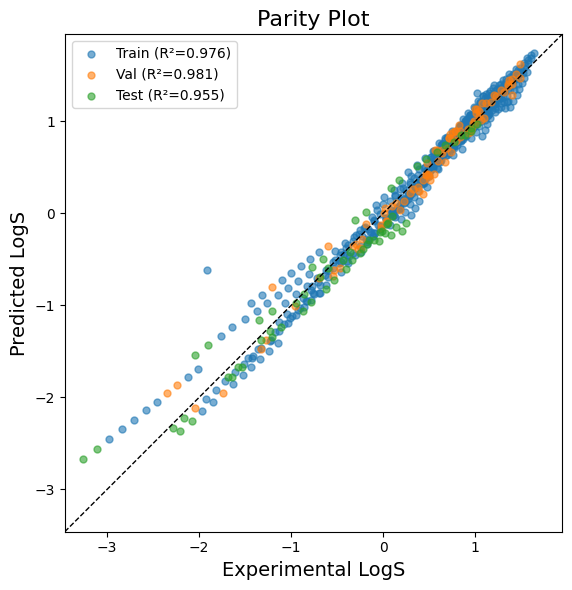

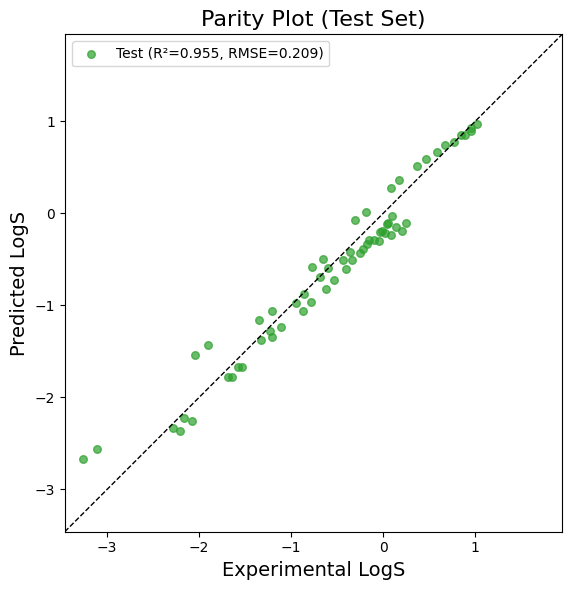


[Mordred Min Temp Split] Train | R²=0.9762 RMSE=0.1354, MAE=0.0942
[Mordred Min Temp Split] Val   | R²=0.9812 RMSE=0.1144, MAE=0.0867
[Mordred Min Temp Split] Test  | R²=0.9551 RMSE=0.2087, MAE=0.1657


In [26]:
# ============================================================================
# Plotting for Mordred Min Temperature Split Model (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# ── Recreate the full arrays from the dataframe ──────────────────────────
# This ensures we have the full dataset, not just a subset
T_full = df['Temperature (K)'].values.reshape(-1, 1)
Y_full = df['LogS'].values.reshape(-1, 1)

print(f"X_fp shape: {X_fp.shape}")
print(f"x1 shape: {x1.shape}")
print(f"T_full shape: {T_full.shape}")
print(f"Y_full shape: {Y_full.shape}")
print(f"df shape: {df.shape}")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [278.15, 283.15]  # Min temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")

# ── Rebuild scaled features using the LOADED scalers ──────────────────────
X_fp_scaled = scaler_fp_temp_loaded.transform(X_fp)
x1_scaled = scaler_comp_temp_loaded.transform(x1)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

# Use the temperature split indices with the full arrays
X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(
    to_t, [X_fp_scaled[idx_temp_train], x1_scaled[idx_temp_train], T_full[idx_temp_train], Y_full[idx_temp_train]]
)
X_fp_val_t, x1_val_t, T_val_t, Y_val_t = map(
    to_t, [X_fp_scaled[idx_temp_val], x1_scaled[idx_temp_val], T_full[idx_temp_val], Y_full[idx_temp_val]]
)
X_fp_test_t, x1_test_t, T_test_t, Y_test_t = map(
    to_t, [X_fp_scaled[idx_temp_test], x1_scaled[idx_temp_test], T_full[idx_temp_test], Y_full[idx_temp_test]]
)

# ── Get predictions ──────────────────────────────────────────────────────
mordred_model_temp_loaded.eval()
with torch.no_grad():
    Y_pred_train = mordred_model_temp_loaded(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_model_temp_loaded(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_model_temp_loaded(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[Mordred Min Temp Split] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(Y_train_np - Y_pred_train)):.4f}")
print(f"[Mordred Min Temp Split] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(Y_val_np - Y_pred_val)):.4f}")
print(f"[Mordred Min Temp Split] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(Y_test_np - Y_pred_test)):.4f}")

In [34]:
# ============================================================================
# STAGE 3: CHEMBERTA MODEL — min TEMPERATURE-BASED SPLIT
# ============================================================================

# ── Subsets reuse the same chemberta_dataset, just different indices ───────
chem_train_dataset_temp = Subset(chemberta_dataset, idx_temp_train)
chem_val_dataset_temp   = Subset(chemberta_dataset, idx_temp_val)
chem_test_dataset_temp  = Subset(chemberta_dataset, idx_temp_test)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=True, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"[Temp split/ChemBERTa] Train: {len(chem_train_dataset_temp)} | Val: {len(chem_val_dataset_temp)} | Test: {len(chem_test_dataset_temp)}")

chemberta_model_temp = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256], mix_emb_dropout=0.3, mix_emb_actfunc='ReLU', mix_emb_size=128,
    physpar_hidden_layers=[64, 32], physpar_dropout=0.2, physpar_actfunc='ReLU'
).to(DEVICE)
print(f"[Temp split/ChemBERTa] Total trainable parameters: {chemberta_model_temp.count_parameters():,}")

print("\n[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)")
chemberta_model_temp.freeze_chemberta()
train_losses_1_temp, val_losses_1_temp, r2_scores_1_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=50, lr=0.001, device=DEVICE, stage_name="[Temp split] Stage 1"
)

print("\n[Temp split/ChemBERTa] STAGE 2: Fine-tuning (unfrozen)")
chemberta_model_temp.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2_temp, val_losses_2_temp, r2_scores_2_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=30, lr=0.0001, device=DEVICE, stage_name="[Temp split] Stage 2",
    best_val_loss=best_val_loss_c_temp, best_weights=best_weights_c_temp
)

chemberta_model_temp.load_state_dict(best_weights_c_temp)
print(f"\n[Temp split/ChemBERTa] Loaded best checkpoint (val loss = {best_val_loss_c_temp:.4f})")

# ── Evaluate on test set (held-out temperatures 278.15 K, 283.15 K) ────────
chemberta_model_temp.eval()
test_preds_c_temp, test_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        test_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        test_targets_c_temp.extend(y.numpy())

test_preds_c_temp, test_targets_c_temp = np.array(test_preds_c_temp), np.array(test_targets_c_temp)
r2_c_temp, rmse_c_temp, mae_c_temp = get_metrics(test_targets_c_temp, test_preds_c_temp)
print(f"[Temp split/ChemBERTa] Test | R²={r2_c_temp:.4f} RMSE={rmse_c_temp:.4f} MAE={mae_c_temp:.4f}")

# ── Train-set predictions too (for a 2x2 parity plot later, if wanted) ────
train_preds_c_temp, train_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        train_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        train_targets_c_temp.extend(y.numpy())

train_preds_c_temp, train_targets_c_temp = np.array(train_preds_c_temp), np.array(train_targets_c_temp)
r2_train_c_temp, rmse_train_c_temp, mae_train_c_temp = get_metrics(train_targets_c_temp, train_preds_c_temp)
print(f"[Temp split/ChemBERTa] Train | R²={r2_train_c_temp:.4f} RMSE={rmse_train_c_temp:.4f} MAE={mae_train_c_temp:.4f}")

[Temp split/ChemBERTa] Train: 528 | Val: 94 | Test: 62
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
[Temp split/ChemBERTa] Total trainable parameters: 45,066,842

[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)
Froze all ChemBERTa layers
[Temp split] Stage 1 Epoch 10/50: Train Loss: 3.0797, Val Loss: 0.8781, Val R²: -0.2554, Best Val: 0.4646, LR: 0.001000
  Pred range: [0.76, 1.00], Target range: [-2.35, 1.48]
[Temp split] Stage 1 Epoch 20/50: Train Loss: 0.8800, Val Loss: 0.3283, Val R²: 0.5269, Best Val: 0.3283, LR: 0.000500
  Pred range: [-1.63, 0.79], Target range: [-2.35, 1.48]
[Temp split] Stage 1 Epoch 30/50: Train Loss: 0.4629, Val Loss: 0.1407, Val R²: 0.7970, Best Val: 0.1399, LR: 0.000500
  Pred range: [-1.61, 1.25], Target range: [-2.35, 1.48]
[Temp split] Stage 1 Epoch 40/50: Train Loss: 0.3954, Val Loss: 0.1341, Val R²: 0.8065, Best Val: 0.1224, LR: 0.000500
  Pred range: [-1.79, 1.09], Target range: [-2.35, 1.48]
[Temp split] Stage 1 Epoch 50/

In [37]:
# ── Save ChemBERTa (temperature split) model + config ───────────────────────
torch.save({
    'model_state_dict': chemberta_model_temp.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'physpar_hidden_layers': [64, 32], 'physpar_dropout': 0.2, 'physpar_actfunc': 'ReLU',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'chemberta_mintemp_split_model.pt')

print("Saved ChemBERTa (temperature split) model to 'chemberta_mintemp_split_model.pt'")

Saved ChemBERTa (temperature split) model to 'chemberta_mintemp_split_model.pt'


In [28]:
# ── Load ChemBERTa (temperature split) model ──────────────────────────────
checkpoint_chemberta_temp = torch.load('chemberta_mintemp_split_model.pt', map_location=DEVICE)

chemberta_model_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_temp['model_config']).to(DEVICE)
chemberta_model_temp_loaded.load_state_dict(checkpoint_chemberta_temp['model_state_dict'])
chemberta_model_temp_loaded.eval()

print("Loaded chemberta_mintemp_split_model — ready for inference/plotting, no training needed.")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_mintemp_split_model — ready for inference/plotting, no training needed.


Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_mintemp_split_model — ready for inference/plotting, no training needed.
Recreated temp split -> Train: 528 | Val: 94 | Test: 62
Test temperatures: [278.15, 283.15]
Dataset size: 684 samples


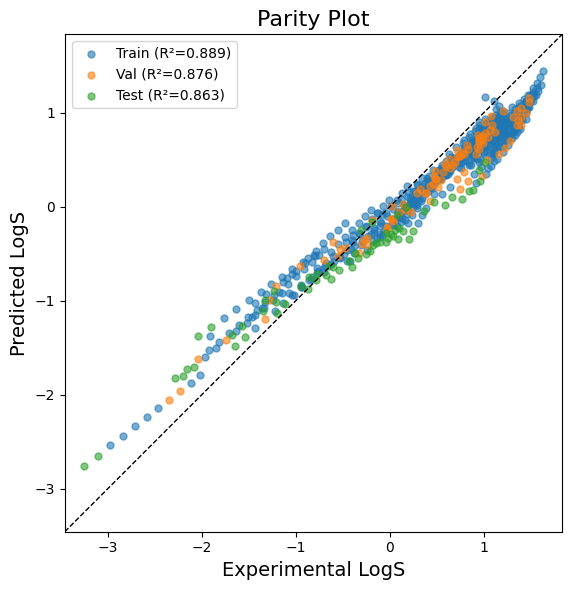

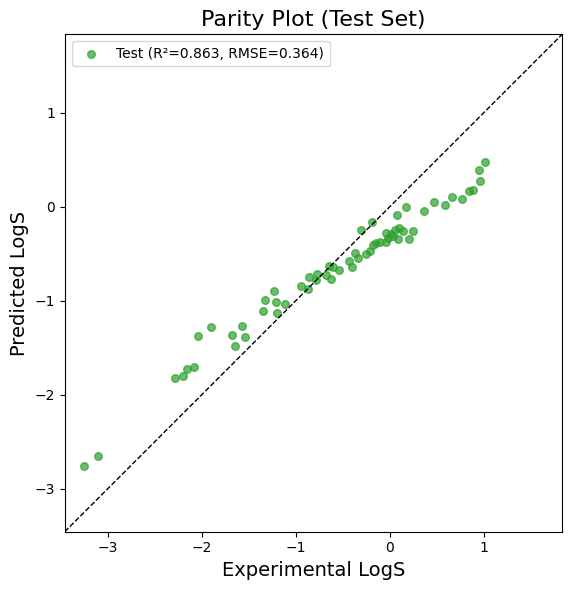


[ChemBERTa (Van't Hoff) - Min Temp] Train | R²=0.8894 RMSE=0.2920, MAE=0.2578
[ChemBERTa (Van't Hoff) - Min Temp] Val   | R²=0.8760 RMSE=0.2938, MAE=0.2580
[ChemBERTa (Van't Hoff) - Min Temp] Test  | R²=0.8631 RMSE=0.3644, MAE=0.3069


In [30]:
# ============================================================================
# Plotting for ChemBERTa (Van't Hoff) — Min Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# ── Load ChemBERTa (min temp split) model ──────────────────────────────────
checkpoint_chemberta_temp = torch.load('chemberta_mintemp_split_model.pt', map_location=DEVICE)

chemberta_model_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_temp['model_config']).to(DEVICE)
chemberta_model_temp_loaded.load_state_dict(checkpoint_chemberta_temp['model_state_dict'])
chemberta_model_temp_loaded.eval()

print("Loaded chemberta_mintemp_split_model — ready for inference/plotting, no training needed.")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [278.15, 283.15]  # Min temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Recreate datasets for ChemBERTa ──────────────────────────────────────────
# Note: ChemBERTa (Van't Hoff) doesn't use a temperature scaler in the dataset
# It uses raw temperature values in the forward pass
chemberta_dataset = SolubilityDataset(df)  # Original dataset without temp scaler

chem_train_dataset_temp = Subset(chemberta_dataset, idx_temp_train)
chem_val_dataset_temp   = Subset(chemberta_dataset, idx_temp_val)
chem_test_dataset_temp  = Subset(chemberta_dataset, idx_temp_test)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ── Get ChemBERTa predictions ──────────────────────────────────────────────
chemberta_model_temp_loaded.eval()

# Train predictions
train_preds, train_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp_loaded(smiles1, smiles2, comp1, T_batch)
        train_preds.extend(predictions.squeeze().cpu().numpy())
        train_targets.extend(y.numpy())

# Val predictions
val_preds, val_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_val_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp_loaded(smiles1, smiles2, comp1, T_batch)
        val_preds.extend(predictions.squeeze().cpu().numpy())
        val_targets.extend(y.numpy())

# Test predictions
test_preds, test_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp_loaded(smiles1, smiles2, comp1, T_batch)
        test_preds.extend(predictions.squeeze().cpu().numpy())
        test_targets.extend(y.numpy())

train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets, train_preds)
r2_val,   rmse_val   = get_metrics(val_targets,   val_preds)
r2_test,  rmse_test  = get_metrics(test_targets,  test_preds)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets, val_targets, test_targets])
all_pred = np.concatenate([train_preds, val_preds, test_preds])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets, train_preds, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets,   val_preds,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets,  test_preds,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa (Van't Hoff) - Min Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets - train_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Min Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets - val_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Min Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")


COMPARISON — TEMPERATURE-BASED SPLIT (278.15K & 283.15K held out)
Model       Set             R²      RMSE       MAE
ChemBERTa   Train       0.8894    0.2920    0.2578
ChemBERTa   Test        0.8631    0.3644    0.3069
Mordred     Train       0.9762    0.1354    0.0942
Mordred     Test        0.9551    0.2087    0.1657


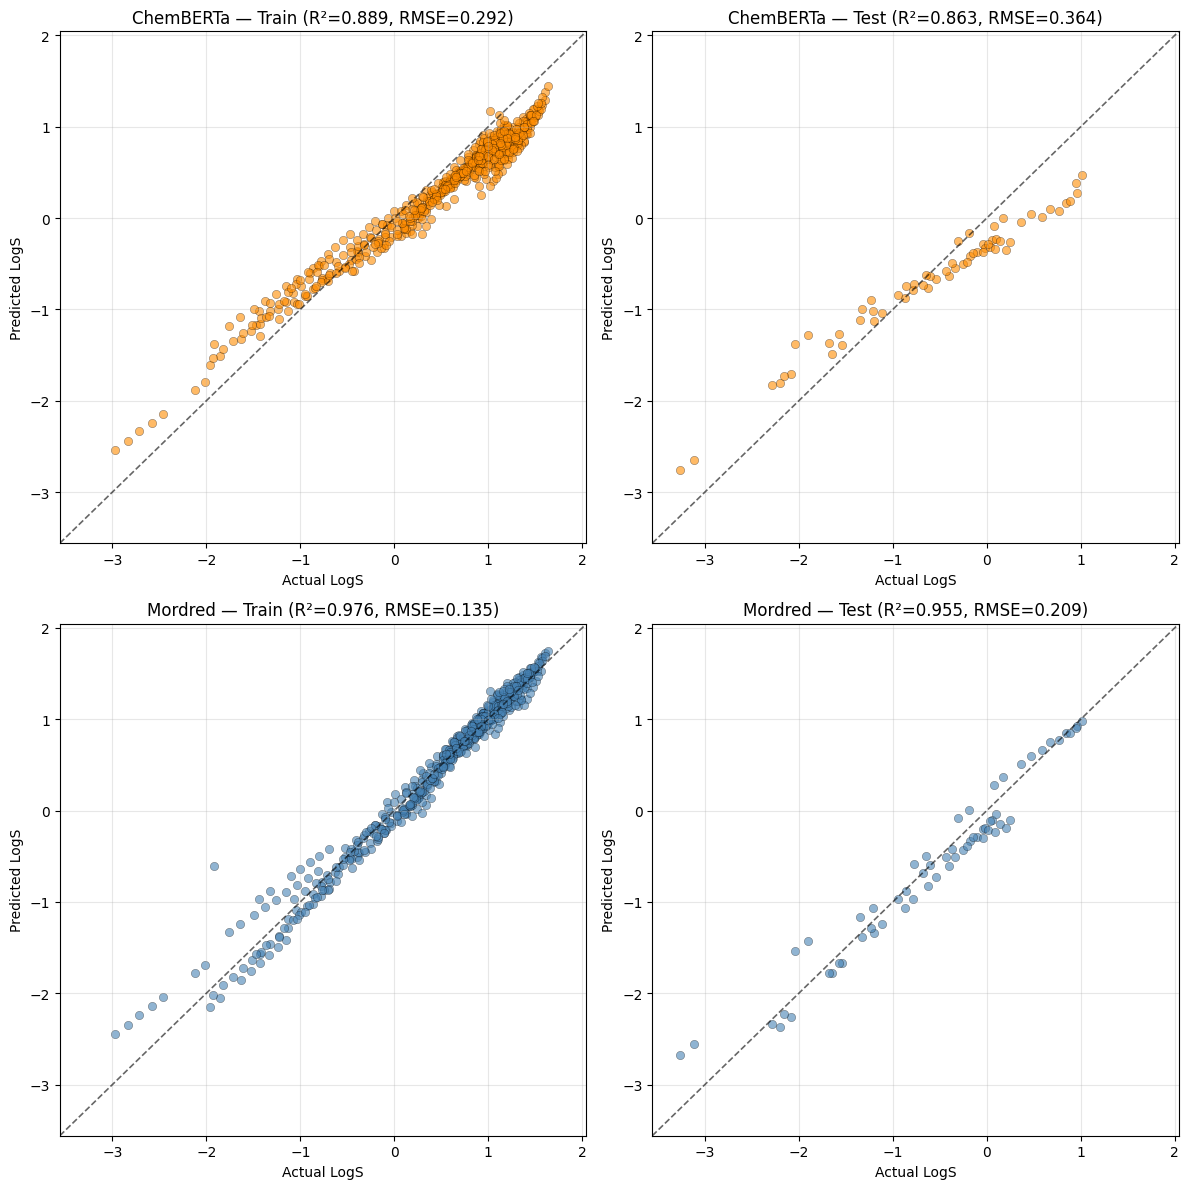

In [39]:
# ============================================================================
# PART 3 (min TEMP SPLIT): SIDE-BY-SIDE COMPARISON — 2x2 GRID (rows: model, cols: train/test)
# ============================================================================

print("\n" + "="*60)
print("COMPARISON — TEMPERATURE-BASED SPLIT (278.15K & 283.15K held out)")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c_temp:>10.4f}{rmse_train_c_temp:>10.4f}{mae_train_c_temp:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c_temp:>10.4f}{rmse_c_temp:>10.4f}{mae_c_temp:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m_temp:>10.4f}{rmse_train_m_temp:>10.4f}{mae_train_m_temp:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m_temp:>10.4f}{rmse_test_m_temp:>10.4f}{mae_test_m_temp:>10.4f}")

# ── 2x2 grid: row 0 = ChemBERTa, row 1 = Mordred | col 0 = Train, col 1 = Test ──
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals_temp = np.concatenate([
    train_targets_c_temp, train_preds_c_temp, test_targets_c_temp, test_preds_c_temp,
    Y_train_np_temp, Y_pred_train_mordred_temp, Y_test_np_temp, Y_pred_test_mordred_temp
])
lims_temp = [all_vals_temp.min() - 0.3, all_vals_temp.max() + 0.3]

plot_specs_temp = [
    (0, 0, train_targets_c_temp, train_preds_c_temp, 'darkorange', 'ChemBERTa', 'Train', r2_train_c_temp, rmse_train_c_temp),
    (0, 1, test_targets_c_temp,  test_preds_c_temp,  'darkorange', 'ChemBERTa', 'Test',  r2_c_temp,        rmse_c_temp),
    (1, 0, Y_train_np_temp,      Y_pred_train_mordred_temp, 'steelblue', 'Mordred', 'Train', r2_train_m_temp, rmse_train_m_temp),
    (1, 1, Y_test_np_temp,       Y_pred_test_mordred_temp,  'steelblue', 'Mordred', 'Test',  r2_test_m_temp,  rmse_test_m_temp),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs_temp:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims_temp, lims_temp, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims_temp); ax.set_ylim(lims_temp)
    ax.set_xlabel('Actual LogS')
    ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_temp_split.png', dpi=150)
plt.show()

In [40]:
# ============================================================================
# max TEMPERATURE-BASED SPLIT (separate from the random split — different names)
# Holds out T = 328.15 K and T = 333.15 K entirely for test.
# ============================================================================
HOLDOUT_TEMPS = [328.15, 333.15]

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)

idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values

# Carve a validation set out of the remaining (non-holdout) rows
idx_temp_train, idx_temp_val = train_test_split(
    idx_temp_remain, test_size=0.15, random_state=42
)

print(f"Temperature split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

Temperature split -> Train: 537 | Val: 95 | Test: 52
Test temperatures: [328.15, 333.15]


In [41]:
# ============================================================================
# STAGE 2: MORDRED MODEL — max TEMPERATURE-BASED SPLIT 
# ============================================================================

T = df['Temperature (K)'].values.reshape(-1, 1)
# ── Scale features, fit ONLY on the temperature-split training rows ────────
scaler_fp_temp = StandardScaler().fit(X_fp[idx_temp_train])
scaler_comp_temp = StandardScaler().fit(x1[idx_temp_train])

X_fp_train_temp = scaler_fp_temp.transform(X_fp[idx_temp_train])
X_fp_val_temp   = scaler_fp_temp.transform(X_fp[idx_temp_val])
X_fp_test_temp  = scaler_fp_temp.transform(X_fp[idx_temp_test])

x1_train_temp = scaler_comp_temp.transform(x1[idx_temp_train])
x1_val_temp   = scaler_comp_temp.transform(x1[idx_temp_val])
x1_test_temp  = scaler_comp_temp.transform(x1[idx_temp_test])

T_train_temp, T_val_temp, T_test_temp = T[idx_temp_train], T[idx_temp_val], T[idx_temp_test]
Y_train_temp, Y_val_temp, Y_test_temp = Y[idx_temp_train], Y[idx_temp_val], Y[idx_temp_test]

print(f"[Temp split/Mordred] Train: {len(X_fp_train_temp)} | Val: {len(X_fp_val_temp)} | Test: {len(X_fp_test_temp)}")

X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t = map(
    to_t, [X_fp_train_temp, x1_train_temp, T_train_temp, Y_train_temp]
)
X_fp_val_temp_t, x1_val_temp_t, T_val_temp_t, Y_val_temp_t = map(
    to_t, [X_fp_val_temp, x1_val_temp, T_val_temp, Y_val_temp]
)
X_fp_test_temp_t, x1_test_temp_t, T_test_temp_t, Y_test_temp_t = map(
    to_t, [X_fp_test_temp, x1_test_temp, T_test_temp, Y_test_temp]
)

train_ds_temp = TensorDataset(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t)
val_ds_temp   = TensorDataset(X_fp_val_temp_t,   x1_val_temp_t,   T_val_temp_t,   Y_val_temp_t)
test_ds_temp  = TensorDataset(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t,  Y_test_temp_t)

train_loader_temp = DataLoader(train_ds_temp, batch_size=32, shuffle=True)
val_loader_temp   = DataLoader(val_ds_temp,   batch_size=len(val_ds_temp),  shuffle=False)
test_loader_temp  = DataLoader(test_ds_temp,  batch_size=len(test_ds_temp), shuffle=False)

# ── Model ────────────────────────────────────────────────────────────────
mordred_model_temp = SolubilityHybridModelV2(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    physpar_hidden_layers=[32], physpar_dropout=0.1, physpar_actfunc='Tanh',
    A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0,
)
print(f"[Temp split/Mordred] Total trainable parameters: {mordred_model_temp.count_parameters()}")

optimizer_temp = torch.optim.Adam(mordred_model_temp.parameters(), lr=1e-3)
criterion = nn.MSELoss()  # reused, stateless

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_temp, patience_counter_temp, best_weights_temp = float('inf'), 0, None
train_losses_temp, val_losses_temp = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_temp.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_temp:
        optimizer_temp.zero_grad()
        Y_pred = mordred_model_temp(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_temp.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_temp)

    mordred_model_temp.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_temp:
            epoch_val_loss = criterion(mordred_model_temp(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_temp.append(epoch_train_loss)
    val_losses_temp.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_temp:
        best_val_loss_temp = epoch_val_loss
        best_weights_temp = {k: v.clone() for k, v in mordred_model_temp.state_dict().items()}
        patience_counter_temp = 0
    else:
        patience_counter_temp += 1
        if patience_counter_temp >= PATIENCE:
            print(f"[Temp split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Temp split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_temp.load_state_dict(best_weights_temp)
print(f"\n[Temp split/Mordred] Best val loss: {best_val_loss_temp:.4f}")

# ── Evaluate ──
mordred_model_temp.eval()
with torch.no_grad():
    Y_pred_train_mordred_temp = mordred_model_temp(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t).numpy().flatten()
    Y_pred_test_mordred_temp  = mordred_model_temp(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t).numpy().flatten()

Y_train_np_temp = Y_train_temp_t.numpy().flatten()
Y_test_np_temp  = Y_test_temp_t.numpy().flatten()

r2_train_m_temp, rmse_train_m_temp, mae_train_m_temp = get_metrics(Y_train_np_temp, Y_pred_train_mordred_temp)
r2_test_m_temp,  rmse_test_m_temp,  mae_test_m_temp  = get_metrics(Y_test_np_temp,  Y_pred_test_mordred_temp)

print(f"[Temp split/Mordred] Train | R²={r2_train_m_temp:.4f} RMSE={rmse_train_m_temp:.4f} MAE={mae_train_m_temp:.4f}")
print(f"[Temp split/Mordred] Test  | R²={r2_test_m_temp:.4f} RMSE={rmse_test_m_temp:.4f} MAE={mae_test_m_temp:.4f}")

[Temp split/Mordred] Train: 537 | Val: 95 | Test: 52
[Temp split/Mordred] Total trainable parameters: 873570
[Temp split/Mordred] Epoch   50 | Train: 0.2001 | Val: 0.0631
[Temp split/Mordred] Epoch  100 | Train: 0.1408 | Val: 0.0283
[Temp split/Mordred] Epoch  150 | Train: 0.1544 | Val: 0.0147
[Temp split/Mordred] Epoch  200 | Train: 0.1113 | Val: 0.0157
[Temp split/Mordred] Epoch  250 | Train: 0.1257 | Val: 0.0146
[Temp split/Mordred] Epoch  300 | Train: 0.0940 | Val: 0.0068
[Temp split/Mordred] Epoch  350 | Train: 0.0950 | Val: 0.0111
[Temp split/Mordred] Early stopping at epoch 372

[Temp split/Mordred] Best val loss: 0.0052
[Temp split/Mordred] Train | R²=0.9920 RMSE=0.0830 MAE=0.0644
[Temp split/Mordred] Test  | R²=0.9544 RMSE=0.1978 MAE=0.1194


In [42]:
# ── Save model weights + scalers + architecture config together ────────────
torch.save({
    'model_state_dict': mordred_model_temp.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'physpar_hidden_layers': [32], 'physpar_dropout': 0.1, 'physpar_actfunc': 'Tanh',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'mordred_max_temp_split_model.pt')

with open('mordred_max_temp_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_temp, 'scaler_comp': scaler_comp_temp}, f)

print("Saved model to 'mordred_max_temp_split_model.pt' and scalers to 'mordred_max_temp_split_scalers.pkl'")

Saved model to 'mordred_max_temp_split_model.pt' and scalers to 'mordred_max_temp_split_scalers.pkl'


In [6]:
# ============================================================================
# Load the model and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load model + scalers (no training required) ─────────────────────────────
checkpoint_temp = torch.load('mordred_max_temp_split_model.pt')

mordred_model_max_temp_loaded = SolubilityHybridModelV2(**checkpoint_temp['model_config'])
mordred_model_max_temp_loaded.load_state_dict(checkpoint_temp['model_state_dict'])
mordred_model_max_temp_loaded.eval()

with open('mordred_max_temp_split_scalers.pkl', 'rb') as f:
    scalers_temp = pickle.load(f)
scaler_fp_max_temp_loaded = scalers_temp['scaler_fp']
scaler_comp_max_temp_loaded = scalers_temp['scaler_comp']

print("Loaded mordred_max_temp_split_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_max_temp_split_model and scalers — ready for inference/plotting, no training needed.


Loaded mordred_max_temp_split_model and scalers
Recreated temp split -> Train: 537 | Val: 95 | Test: 52
Test temperatures: [328.15, 333.15]


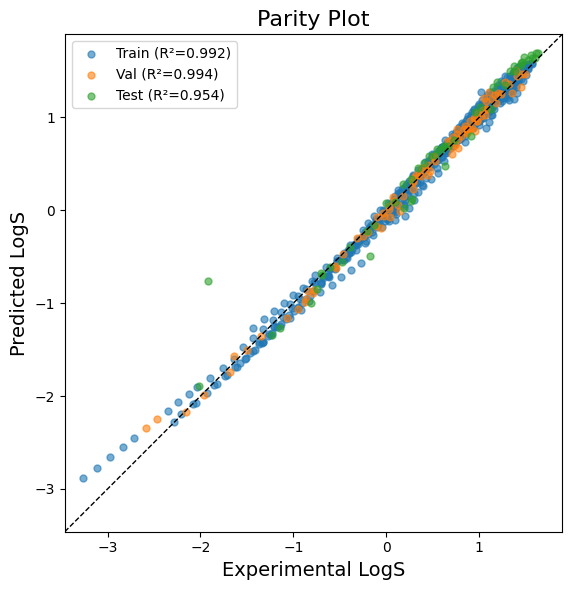

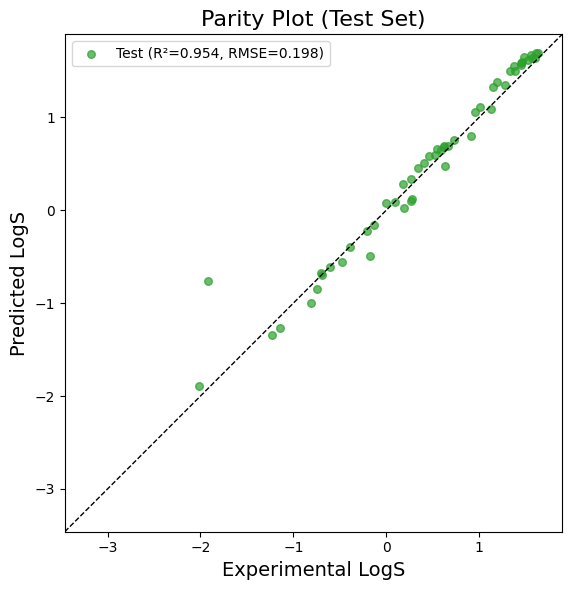


[Mordred (Van't Hoff) - Max Temp] Train | R²=0.9920 RMSE=0.0830, MAE=0.0644
[Mordred (Van't Hoff) - Max Temp] Val   | R²=0.9938 RMSE=0.0722, MAE=0.0560
[Mordred (Van't Hoff) - Max Temp] Test  | R²=0.9544 RMSE=0.1978, MAE=0.1194


In [14]:
# ============================================================================
# Plotting for Mordred (Van't Hoff) — Max Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split

# ── Load Mordred (Van't Hoff) max temp split model and scalers ──────────────
checkpoint_temp = torch.load('mordred_max_temp_split_model.pt')

mordred_model_max_temp_loaded = SolubilityHybridModelV2(**checkpoint_temp['model_config'])
mordred_model_max_temp_loaded.load_state_dict(checkpoint_temp['model_state_dict'])
mordred_model_max_temp_loaded.eval()

with open('mordred_max_temp_split_scalers.pkl', 'rb') as f:
    scalers_temp = pickle.load(f)
scaler_fp_max_temp_loaded = scalers_temp['scaler_fp']
scaler_comp_max_temp_loaded = scalers_temp['scaler_comp']

print("Loaded mordred_max_temp_split_model and scalers")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [328.15, 333.15]  # Max temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Rebuild full arrays from dataframe ──────────────────────────────────────
T_full = df['Temperature (K)'].values.reshape(-1, 1)
Y_full = df['LogS'].values.reshape(-1, 1)

# ── Scale features using the LOADED scalers ─────────────────────────────────
# Note: Van't Hoff model uses raw temperature (not scaled) in forward pass
X_fp_scaled = scaler_fp_max_temp_loaded.transform(X_fp)
x1_scaled = scaler_comp_max_temp_loaded.transform(x1)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

# ── Create tensors for Mordred (Van't Hoff) ─────────────────────────────────
# T is NOT scaled for Van't Hoff model
X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(
    to_t, [X_fp_scaled[idx_temp_train], x1_scaled[idx_temp_train], T_full[idx_temp_train], Y_full[idx_temp_train]]
)
X_fp_val_t, x1_val_t, T_val_t, Y_val_t = map(
    to_t, [X_fp_scaled[idx_temp_val], x1_scaled[idx_temp_val], T_full[idx_temp_val], Y_full[idx_temp_val]]
)
X_fp_test_t, x1_test_t, T_test_t, Y_test_t = map(
    to_t, [X_fp_scaled[idx_temp_test], x1_scaled[idx_temp_test], T_full[idx_temp_test], Y_full[idx_temp_test]]
)

# ── Get Mordred predictions ──────────────────────────────────────────────────
mordred_model_max_temp_loaded.eval()
with torch.no_grad():
    Y_pred_train = mordred_model_max_temp_loaded(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_model_max_temp_loaded(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_model_max_temp_loaded(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[Mordred (Van't Hoff) - Max Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(Y_train_np - Y_pred_train)):.4f}")
print(f"[Mordred (Van't Hoff) - Max Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(Y_val_np - Y_pred_val)):.4f}")
print(f"[Mordred (Van't Hoff) - Max Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(Y_test_np - Y_pred_test)):.4f}")

In [44]:
# ============================================================================
# STAGE 3: CHEMBERTA MODEL — max TEMPERATURE-BASED SPLIT
# ============================================================================

# ── Subsets reuse the same chemberta_dataset, just different indices ───────
chem_train_dataset_temp = Subset(chemberta_dataset, idx_temp_train)
chem_val_dataset_temp   = Subset(chemberta_dataset, idx_temp_val)
chem_test_dataset_temp  = Subset(chemberta_dataset, idx_temp_test)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=True, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"[Temp split/ChemBERTa] Train: {len(chem_train_dataset_temp)} | Val: {len(chem_val_dataset_temp)} | Test: {len(chem_test_dataset_temp)}")

chemberta_model_temp = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256], mix_emb_dropout=0.3, mix_emb_actfunc='ReLU', mix_emb_size=128,
    physpar_hidden_layers=[64, 32], physpar_dropout=0.2, physpar_actfunc='ReLU'
).to(DEVICE)
print(f"[Temp split/ChemBERTa] Total trainable parameters: {chemberta_model_temp.count_parameters():,}")

print("\n[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)")
chemberta_model_temp.freeze_chemberta()
train_losses_1_temp, val_losses_1_temp, r2_scores_1_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=50, lr=0.001, device=DEVICE, stage_name="[Temp split] Stage 1"
)

print("\n[Temp split/ChemBERTa] STAGE 2: Fine-tuning (unfrozen)")
chemberta_model_temp.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2_temp, val_losses_2_temp, r2_scores_2_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=30, lr=0.0001, device=DEVICE, stage_name="[Temp split] Stage 2",
    best_val_loss=best_val_loss_c_temp, best_weights=best_weights_c_temp
)

chemberta_model_temp.load_state_dict(best_weights_c_temp)
print(f"\n[Temp split/ChemBERTa] Loaded best checkpoint (val loss = {best_val_loss_c_temp:.4f})")

# ── Evaluate on test set (held-out temperatures 278.15 K, 283.15 K) ────────
chemberta_model_temp.eval()
test_preds_c_temp, test_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        test_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        test_targets_c_temp.extend(y.numpy())

test_preds_c_temp, test_targets_c_temp = np.array(test_preds_c_temp), np.array(test_targets_c_temp)
r2_c_temp, rmse_c_temp, mae_c_temp = get_metrics(test_targets_c_temp, test_preds_c_temp)
print(f"[Temp split/ChemBERTa] Test | R²={r2_c_temp:.4f} RMSE={rmse_c_temp:.4f} MAE={mae_c_temp:.4f}")

# ── Train-set predictions too (for a 2x2 parity plot later, if wanted) ────
train_preds_c_temp, train_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        train_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        train_targets_c_temp.extend(y.numpy())

train_preds_c_temp, train_targets_c_temp = np.array(train_preds_c_temp), np.array(train_targets_c_temp)
r2_train_c_temp, rmse_train_c_temp, mae_train_c_temp = get_metrics(train_targets_c_temp, train_preds_c_temp)
print(f"[Temp split/ChemBERTa] Train | R²={r2_train_c_temp:.4f} RMSE={rmse_train_c_temp:.4f} MAE={mae_train_c_temp:.4f}")

[Temp split/ChemBERTa] Train: 537 | Val: 95 | Test: 52
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
[Temp split/ChemBERTa] Total trainable parameters: 45,066,842

[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)
Froze all ChemBERTa layers
[Temp split] Stage 1 Epoch 10/50: Train Loss: 3.1182, Val Loss: 1.0764, Val R²: -0.2759, Best Val: 1.0764, LR: 0.001000
  Pred range: [0.70, 0.95], Target range: [-2.58, 1.49]
[Temp split] Stage 1 Epoch 20/50: Train Loss: 3.2493, Val Loss: 1.0764, Val R²: -0.2759, Best Val: 1.0764, LR: 0.000500
  Pred range: [0.70, 0.95], Target range: [-2.58, 1.49]
[Temp split] Stage 1 Epoch 30/50: Train Loss: 3.1139, Val Loss: 1.0764, Val R²: -0.2759, Best Val: 1.0764, LR: 0.000250
  Pred range: [0.70, 0.95], Target range: [-2.58, 1.49]
[Temp split] Stage 1 Epoch 40/50: Train Loss: 2.0087, Val Loss: 0.4191, Val R²: 0.5027, Best Val: 0.2332, LR: 0.000250
  Pred range: [-1.17, 0.95], Target range: [-2.58, 1.49]
[Temp split] Stage 1 Epoch 50/

In [45]:
# ── Save ChemBERTa (max temperature split) model + config ───────────────────
torch.save({
    'model_state_dict': chemberta_model_temp.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'physpar_hidden_layers': [64, 32], 'physpar_dropout': 0.2, 'physpar_actfunc': 'ReLU',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'chemberta_max_temp_split_model.pt')

print("Saved ChemBERTa (max temperature split) model to 'chemberta_max_temp_split_model.pt'")

Saved ChemBERTa (max temperature split) model to 'chemberta_max_temp_split_model.pt'


In [ ]:
# ============================================================================
# Load ChemBERTa (max temperature split) model — no training required
# ============================================================================
import pickle

# ── Load ChemBERTa (max temperature split) model ──────────────────────────
checkpoint_chemberta_max_temp = torch.load('chemberta_max_temp_split_model.pt', map_location=DEVICE)

chemberta_model_max_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_max_temp['model_config']).to(DEVICE)
chemberta_model_max_temp_loaded.load_state_dict(checkpoint_chemberta_max_temp['model_state_dict'])
chemberta_model_max_temp_loaded.eval()

print("Loaded chemberta_max_temp_split_model — ready for inference/plotting, no training needed.")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_max_temp_split_model — ready for inference/plotting, no training needed.


Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_max_temp_split_model — ready for inference/plotting, no training needed.
Recreated temp split -> Train: 537 | Val: 95 | Test: 52
Test temperatures: [328.15, 333.15]
Dataset size: 684 samples


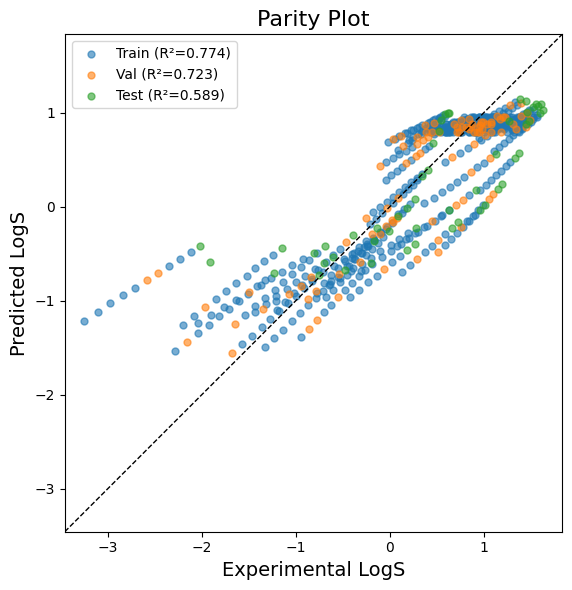

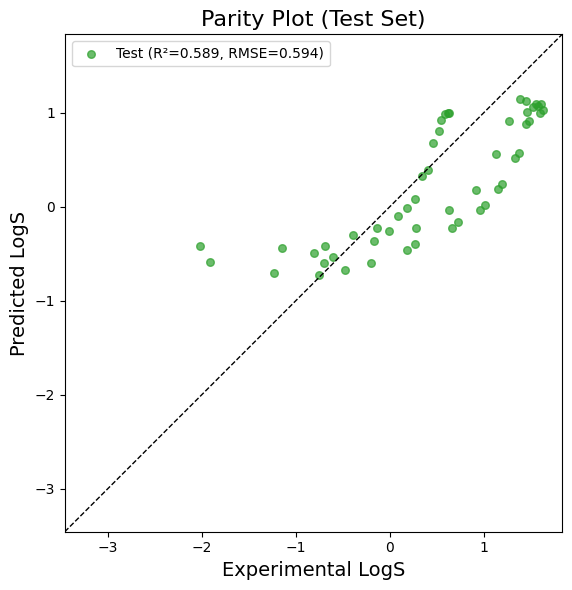


[ChemBERTa (Van't Hoff) - Max Temp] Train | R²=0.7736 RMSE=0.4425, MAE=0.3297
[ChemBERTa (Van't Hoff) - Max Temp] Val   | R²=0.7234 RMSE=0.4839, MAE=0.3576
[ChemBERTa (Van't Hoff) - Max Temp] Test  | R²=0.5887 RMSE=0.5939, MAE=0.4908


In [15]:
# ============================================================================
# Plotting for ChemBERTa (Van't Hoff) — Max Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# ── Load ChemBERTa (Van't Hoff) max temp split model ──────────────────────
checkpoint_chemberta_max_temp = torch.load('chemberta_max_temp_split_model.pt', map_location=DEVICE)

chemberta_model_max_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_max_temp['model_config']).to(DEVICE)
chemberta_model_max_temp_loaded.load_state_dict(checkpoint_chemberta_max_temp['model_state_dict'])
chemberta_model_max_temp_loaded.eval()

print("Loaded chemberta_max_temp_split_model — ready for inference/plotting, no training needed.")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [328.15, 333.15]  # Max temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Recreate datasets for ChemBERTa (Van't Hoff) ────────────────────────────
# Note: Van't Hoff ChemBERTa uses the dataset without temperature scaler
chemberta_dataset = SolubilityDataset(df)  # Original dataset without temp scaler

chem_train_dataset_temp = Subset(chemberta_dataset, idx_temp_train)
chem_val_dataset_temp   = Subset(chemberta_dataset, idx_temp_val)
chem_test_dataset_temp  = Subset(chemberta_dataset, idx_temp_test)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ── Get ChemBERTa predictions ──────────────────────────────────────────────
chemberta_model_max_temp_loaded.eval()

# Train predictions
train_preds, train_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        train_preds.extend(predictions.squeeze().cpu().numpy())
        train_targets.extend(y.numpy())

# Val predictions
val_preds, val_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_val_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        val_preds.extend(predictions.squeeze().cpu().numpy())
        val_targets.extend(y.numpy())

# Test predictions
test_preds, test_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        test_preds.extend(predictions.squeeze().cpu().numpy())
        test_targets.extend(y.numpy())

train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets, train_preds)
r2_val,   rmse_val   = get_metrics(val_targets,   val_preds)
r2_test,  rmse_test  = get_metrics(test_targets,  test_preds)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets, val_targets, test_targets])
all_pred = np.concatenate([train_preds, val_preds, test_preds])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets, train_preds, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets,   val_preds,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets,  test_preds,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa (Van't Hoff) - Max Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets - train_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Max Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets - val_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Max Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")


COMPARISON — TEMPERATURE-BASED SPLIT (328.15K & 333.15K held out)
Model       Set             R²      RMSE       MAE
ChemBERTa   Train       0.7736    0.4425    0.3297
ChemBERTa   Test        0.5887    0.5939    0.4908
Mordred     Train       0.9920    0.0830    0.0644
Mordred     Test        0.9544    0.1978    0.1194


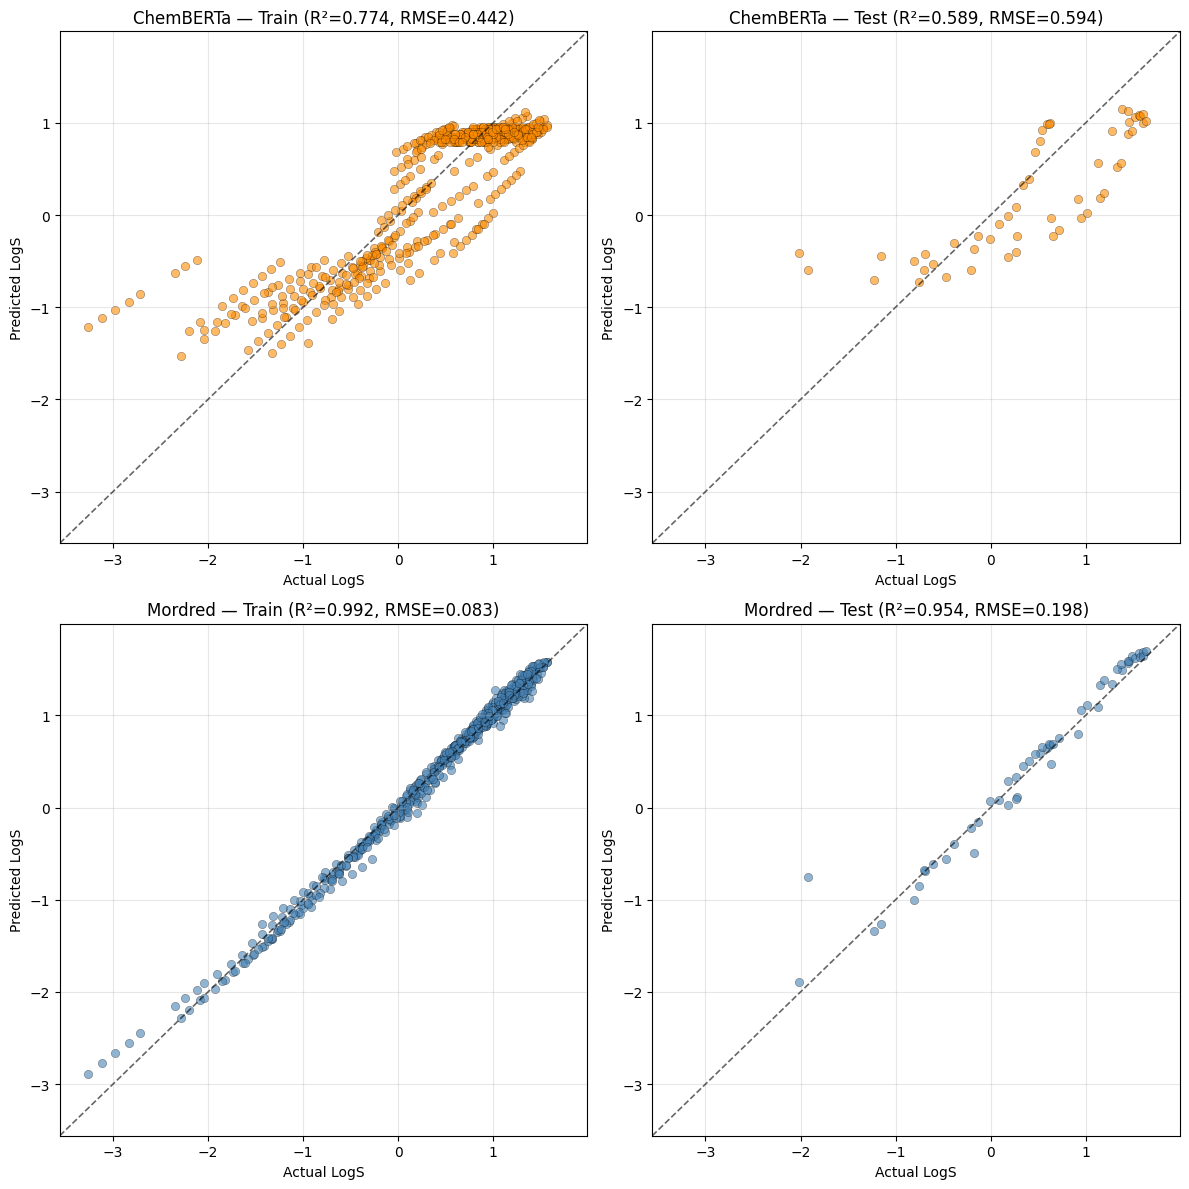

In [47]:
# ============================================================================
# PART 3 (max TEMP SPLIT): SIDE-BY-SIDE COMPARISON — 2x2 GRID (rows: model, cols: train/test)
# ============================================================================

print("\n" + "="*60)
print("COMPARISON — TEMPERATURE-BASED SPLIT (328.15K & 333.15K held out)")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c_temp:>10.4f}{rmse_train_c_temp:>10.4f}{mae_train_c_temp:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c_temp:>10.4f}{rmse_c_temp:>10.4f}{mae_c_temp:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m_temp:>10.4f}{rmse_train_m_temp:>10.4f}{mae_train_m_temp:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m_temp:>10.4f}{rmse_test_m_temp:>10.4f}{mae_test_m_temp:>10.4f}")

# ── 2x2 grid: row 0 = ChemBERTa, row 1 = Mordred | col 0 = Train, col 1 = Test ──
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals_temp = np.concatenate([
    train_targets_c_temp, train_preds_c_temp, test_targets_c_temp, test_preds_c_temp,
    Y_train_np_temp, Y_pred_train_mordred_temp, Y_test_np_temp, Y_pred_test_mordred_temp
])
lims_temp = [all_vals_temp.min() - 0.3, all_vals_temp.max() + 0.3]

plot_specs_temp = [
    (0, 0, train_targets_c_temp, train_preds_c_temp, 'darkorange', 'ChemBERTa', 'Train', r2_train_c_temp, rmse_train_c_temp),
    (0, 1, test_targets_c_temp,  test_preds_c_temp,  'darkorange', 'ChemBERTa', 'Test',  r2_c_temp,        rmse_c_temp),
    (1, 0, Y_train_np_temp,      Y_pred_train_mordred_temp, 'steelblue', 'Mordred', 'Train', r2_train_m_temp, rmse_train_m_temp),
    (1, 1, Y_test_np_temp,       Y_pred_test_mordred_temp,  'steelblue', 'Mordred', 'Test',  r2_test_m_temp,  rmse_test_m_temp),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs_temp:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims_temp, lims_temp, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims_temp); ax.set_ylim(lims_temp)
    ax.set_xlabel('Actual LogS')
    ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_temp_split.png', dpi=150)
plt.show()

In [31]:
# ============================================================================
# SOLVENT-PAIR-BASED SPLIT (separate from random & temperature splits — different names)
# Holds out ALL rows where the solvent pair is Water + 2-Propanol, for any composition/temperature.
# ============================================================================
from rdkit import Chem

WATER_SMILES = "O"
ISOPROPANOL_SMILES = "CC(C)O"

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

water_canon = canon(WATER_SMILES)
ipa_canon = canon(ISOPROPANOL_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == water_canon) & (df['_smiles2_canon'] == ipa_canon)) |
    ((df['_smiles1_canon'] == ipa_canon) & (df['_smiles2_canon'] == water_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values

print(f"Rows found for Water + 2-Propanol pair: {len(idx_solv_test)}")
if len(idx_solv_test) == 0:
    print("WARNING: no rows matched — check that this solvent pair actually exists in the dataset.")
    print("Unique solvent pairs in the dataset:")
    print(df[['SMILES_1', 'SMILES_2']].drop_duplicates().to_string())

# Carve a validation set out of the remaining (non-holdout) rows
idx_solv_train, idx_solv_val = train_test_split(
    idx_solv_remain, test_size=0.15, random_state=42
)

print(f"Solvent-pair split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

# Clean up helper columns (not needed downstream)
df.drop(columns=['_smiles1_canon', '_smiles2_canon'], inplace=True)

Rows found for Water + 2-Propanol pair: 121
Solvent-pair split -> Train: 478 | Val: 85 | Test: 121


In [49]:
# ============================================================================
# STAGE 4: MORDRED MODEL — SOLVENT-PAIR-BASED SPLIT (Water + 2-Propanol held out)
# ============================================================================

scaler_fp_solv = StandardScaler().fit(X_fp[idx_solv_train])
scaler_comp_solv = StandardScaler().fit(x1[idx_solv_train])

X_fp_train_solv = scaler_fp_solv.transform(X_fp[idx_solv_train])
X_fp_val_solv   = scaler_fp_solv.transform(X_fp[idx_solv_val])
X_fp_test_solv  = scaler_fp_solv.transform(X_fp[idx_solv_test])

x1_train_solv = scaler_comp_solv.transform(x1[idx_solv_train])
x1_val_solv   = scaler_comp_solv.transform(x1[idx_solv_val])
x1_test_solv  = scaler_comp_solv.transform(x1[idx_solv_test])

T_train_solv, T_val_solv, T_test_solv = T[idx_solv_train], T[idx_solv_val], T[idx_solv_test]
Y_train_solv, Y_val_solv, Y_test_solv = Y[idx_solv_train], Y[idx_solv_val], Y[idx_solv_test]

print(f"[Solvent split/Mordred] Train: {len(X_fp_train_solv)} | Val: {len(X_fp_val_solv)} | Test: {len(X_fp_test_solv)}")

X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t = map(
    to_t, [X_fp_train_solv, x1_train_solv, T_train_solv, Y_train_solv]
)
X_fp_val_solv_t, x1_val_solv_t, T_val_solv_t, Y_val_solv_t = map(
    to_t, [X_fp_val_solv, x1_val_solv, T_val_solv, Y_val_solv]
)
X_fp_test_solv_t, x1_test_solv_t, T_test_solv_t, Y_test_solv_t = map(
    to_t, [X_fp_test_solv, x1_test_solv, T_test_solv, Y_test_solv]
)

train_ds_solv = TensorDataset(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t)
val_ds_solv   = TensorDataset(X_fp_val_solv_t,   x1_val_solv_t,   T_val_solv_t,   Y_val_solv_t)
test_ds_solv  = TensorDataset(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t,  Y_test_solv_t)

train_loader_solv = DataLoader(train_ds_solv, batch_size=32, shuffle=True)
val_loader_solv   = DataLoader(val_ds_solv,   batch_size=len(val_ds_solv),  shuffle=False)
test_loader_solv  = DataLoader(test_ds_solv,  batch_size=len(test_ds_solv), shuffle=False)

mordred_model_solv = SolubilityHybridModelV2(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    physpar_hidden_layers=[32], physpar_dropout=0.1, physpar_actfunc='Tanh',
    A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0,
)
print(f"[Solvent split/Mordred] Total trainable parameters: {mordred_model_solv.count_parameters()}")

optimizer_solv = torch.optim.Adam(mordred_model_solv.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_solv, patience_counter_solv, best_weights_solv = float('inf'), 0, None
train_losses_solv, val_losses_solv = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_solv.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_solv:
        optimizer_solv.zero_grad()
        Y_pred = mordred_model_solv(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_solv.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_solv)

    mordred_model_solv.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_solv:
            epoch_val_loss = criterion(mordred_model_solv(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_solv.append(epoch_train_loss)
    val_losses_solv.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_solv:
        best_val_loss_solv = epoch_val_loss
        best_weights_solv = {k: v.clone() for k, v in mordred_model_solv.state_dict().items()}
        patience_counter_solv = 0
    else:
        patience_counter_solv += 1
        if patience_counter_solv >= PATIENCE:
            print(f"[Solvent split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Solvent split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_solv.load_state_dict(best_weights_solv)
print(f"\n[Solvent split/Mordred] Best val loss: {best_val_loss_solv:.4f}")

mordred_model_solv.eval()
with torch.no_grad():
    Y_pred_train_mordred_solv = mordred_model_solv(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t).numpy().flatten()
    Y_pred_test_mordred_solv  = mordred_model_solv(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t).numpy().flatten()

Y_train_np_solv = Y_train_solv_t.numpy().flatten()
Y_test_np_solv  = Y_test_solv_t.numpy().flatten()

r2_train_m_solv, rmse_train_m_solv, mae_train_m_solv = get_metrics(Y_train_np_solv, Y_pred_train_mordred_solv)
r2_test_m_solv,  rmse_test_m_solv,  mae_test_m_solv  = get_metrics(Y_test_np_solv,  Y_pred_test_mordred_solv)

print(f"[Solvent split/Mordred] Train | R²={r2_train_m_solv:.4f} RMSE={rmse_train_m_solv:.4f} MAE={mae_train_m_solv:.4f}")
print(f"[Solvent split/Mordred] Test  | R²={r2_test_m_solv:.4f} RMSE={rmse_test_m_solv:.4f} MAE={mae_test_m_solv:.4f}")

[Solvent split/Mordred] Train: 478 | Val: 85 | Test: 121
[Solvent split/Mordred] Total trainable parameters: 873570
[Solvent split/Mordred] Epoch   50 | Train: 0.2297 | Val: 0.0328
[Solvent split/Mordred] Epoch  100 | Train: 0.1722 | Val: 0.0155
[Solvent split/Mordred] Early stopping at epoch 133

[Solvent split/Mordred] Best val loss: 0.0101
[Solvent split/Mordred] Train | R²=0.9584 RMSE=0.1679 MAE=0.1015
[Solvent split/Mordred] Test  | R²=0.7715 RMSE=0.4428 MAE=0.3374


In [50]:
# ── Save model weights + scalers + architecture config together ────────────
torch.save({
    'model_state_dict': mordred_model_solv.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'physpar_hidden_layers': [32], 'physpar_dropout': 0.1, 'physpar_actfunc': 'Tanh',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'mordred_water_prop_model.pt')

with open('mordred_water_prop_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_solv, 'scaler_comp': scaler_comp_solv}, f)

print("Saved model to 'mordred_water_prop_model.pt' and scalers to 'mordred_water_prop_scalers.pkl'")


Saved model to 'mordred_water_prop_model.pt' and scalers to 'mordred_water_prop_scalers.pkl'


In [32]:
# ============================================================================
# Load the model and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load model + scalers (no training required) ─────────────────────────────
checkpoint_solv = torch.load('mordred_water_prop_model.pt')

mordred_model_solv_loaded = SolubilityHybridModelV2(**checkpoint_solv['model_config'])
mordred_model_solv_loaded.load_state_dict(checkpoint_solv['model_state_dict'])
mordred_model_solv_loaded.eval()

with open('mordred_water_prop_scalers.pkl', 'rb') as f:
    scalers_solv = pickle.load(f)
scaler_fp_solv_loaded = scalers_solv['scaler_fp']
scaler_comp_solv_loaded = scalers_solv['scaler_comp']

print("Loaded mordred_water_prop_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_water_prop_model and scalers — ready for inference/plotting, no training needed.


Loaded mordred_water_prop_model and scalers
Recreated solvent split -> Train: 478 | Val: 85 | Test: 121


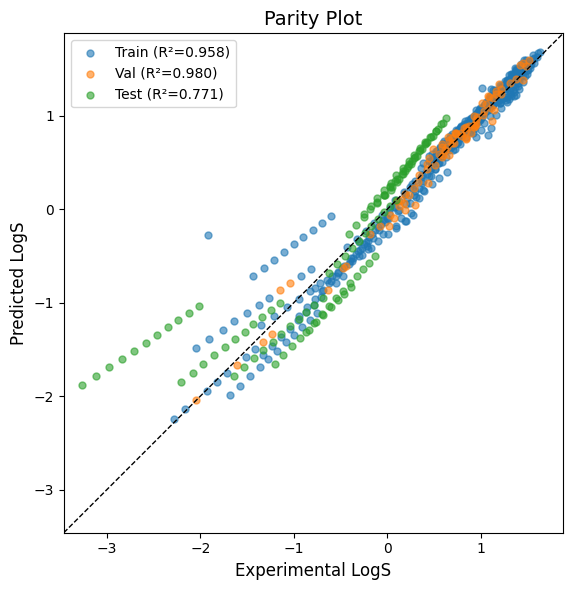

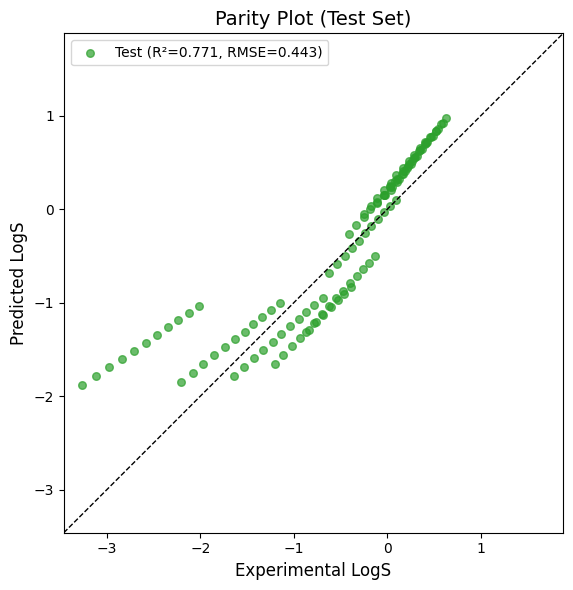


[Mordred (Van't Hoff) - Water + 2-Propanol] Train | R²=0.9584 RMSE=0.1679, MAE=0.1015
[Mordred (Van't Hoff) - Water + 2-Propanol] Val   | R²=0.9797 RMSE=0.1006, MAE=0.0796
[Mordred (Van't Hoff) - Water + 2-Propanol] Test  | R²=0.7715 RMSE=0.4428, MAE=0.3374


In [35]:
# ============================================================================
# Plotting for Mordred (Van't Hoff) — Water + 2-Propanol Solvent Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from rdkit import Chem

# ── Load Mordred (Van't Hoff) solvent split model and scalers ──────────────
checkpoint_solv = torch.load('mordred_water_prop_model.pt')

mordred_model_solv_loaded = SolubilityHybridModelV2(**checkpoint_solv['model_config'])
mordred_model_solv_loaded.load_state_dict(checkpoint_solv['model_state_dict'])
mordred_model_solv_loaded.eval()

with open('mordred_water_prop_scalers.pkl', 'rb') as f:
    scalers_solv = pickle.load(f)
scaler_fp_solv_loaded = scalers_solv['scaler_fp']
scaler_comp_solv_loaded = scalers_solv['scaler_comp']

print("Loaded mordred_water_prop_model and scalers")

# ── Recreate the solvent split indices ──────────────────────────────────────
WATER_SMILES = "O"
ISOPROPANOL_SMILES = "CC(C)O"

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

water_canon = canon(WATER_SMILES)
ipa_canon = canon(ISOPROPANOL_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == water_canon) & (df['_smiles2_canon'] == ipa_canon)) |
    ((df['_smiles1_canon'] == ipa_canon) & (df['_smiles2_canon'] == water_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values
idx_solv_train, idx_solv_val = train_test_split(idx_solv_remain, test_size=0.15, random_state=42)

print(f"Recreated solvent split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

# ── Rebuild full arrays from dataframe ──────────────────────────────────────
T_full = df['Temperature (K)'].values.reshape(-1, 1)
Y_full = df['LogS'].values.reshape(-1, 1)

# ── Scale features using the LOADED scalers ─────────────────────────────────
# Note: Van't Hoff model uses raw temperature (not scaled) in forward pass
X_fp_scaled = scaler_fp_solv_loaded.transform(X_fp)
x1_scaled = scaler_comp_solv_loaded.transform(x1)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

# ── Create tensors for Mordred (Van't Hoff) ─────────────────────────────────
# T is NOT scaled for Van't Hoff model
X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(
    to_t, [X_fp_scaled[idx_solv_train], x1_scaled[idx_solv_train], T_full[idx_solv_train], Y_full[idx_solv_train]]
)
X_fp_val_t, x1_val_t, T_val_t, Y_val_t = map(
    to_t, [X_fp_scaled[idx_solv_val], x1_scaled[idx_solv_val], T_full[idx_solv_val], Y_full[idx_solv_val]]
)
X_fp_test_t, x1_test_t, T_test_t, Y_test_t = map(
    to_t, [X_fp_scaled[idx_solv_test], x1_scaled[idx_solv_test], T_full[idx_solv_test], Y_full[idx_solv_test]]
)

# ── Get Mordred predictions ──────────────────────────────────────────────────
mordred_model_solv_loaded.eval()
with torch.no_grad():
    Y_pred_train = mordred_model_solv_loaded(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_model_solv_loaded(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_model_solv_loaded(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS', fontsize=12)
plt.title('Parity Plot', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS', fontsize=12)
plt.title('Parity Plot (Test Set)', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[Mordred (Van't Hoff) - Water + 2-Propanol] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(Y_train_np - Y_pred_train)):.4f}")
print(f"[Mordred (Van't Hoff) - Water + 2-Propanol] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(Y_val_np - Y_pred_val)):.4f}")
print(f"[Mordred (Van't Hoff) - Water + 2-Propanol] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(Y_test_np - Y_pred_test)):.4f}")

In [52]:
# ============================================================================
# STAGE 5: CHEMBERTA MODEL — SOLVENT-PAIR-BASED SPLIT (Water + 2-Propanol held out)
# ============================================================================

chem_train_dataset_solv = Subset(chemberta_dataset, idx_solv_train)
chem_val_dataset_solv   = Subset(chemberta_dataset, idx_solv_val)
chem_test_dataset_solv  = Subset(chemberta_dataset, idx_solv_test)

chem_train_loader_solv = DataLoader(chem_train_dataset_solv, batch_size=32, shuffle=True, collate_fn=collate_fn)
chem_val_loader_solv   = DataLoader(chem_val_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_solv  = DataLoader(chem_test_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"[Solvent split/ChemBERTa] Train: {len(chem_train_dataset_solv)} | Val: {len(chem_val_dataset_solv)} | Test: {len(chem_test_dataset_solv)}")

chemberta_model_solv = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256], mix_emb_dropout=0.3, mix_emb_actfunc='ReLU', mix_emb_size=128,
    physpar_hidden_layers=[64, 32], physpar_dropout=0.2, physpar_actfunc='ReLU'
).to(DEVICE)
print(f"[Solvent split/ChemBERTa] Total trainable parameters: {chemberta_model_solv.count_parameters():,}")

print("\n[Solvent split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)")
chemberta_model_solv.freeze_chemberta()
train_losses_1_solv, val_losses_1_solv, r2_scores_1_solv, best_val_loss_c_solv, best_weights_c_solv = train_model(
    chemberta_model_solv, chem_train_loader_solv, chem_val_loader_solv,
    epochs=50, lr=0.001, device=DEVICE, stage_name="[Solvent split] Stage 1"
)

print("\n[Solvent split/ChemBERTa] STAGE 2: Fine-tuning (unfrozen)")
chemberta_model_solv.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2_solv, val_losses_2_solv, r2_scores_2_solv, best_val_loss_c_solv, best_weights_c_solv = train_model(
    chemberta_model_solv, chem_train_loader_solv, chem_val_loader_solv,
    epochs=30, lr=0.0001, device=DEVICE, stage_name="[Solvent split] Stage 2",
    best_val_loss=best_val_loss_c_solv, best_weights=best_weights_c_solv
)

chemberta_model_solv.load_state_dict(best_weights_c_solv)
print(f"\n[Solvent split/ChemBERTa] Loaded best checkpoint (val loss = {best_val_loss_c_solv:.4f})")

chemberta_model_solv.eval()
test_preds_c_solv, test_targets_c_solv = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv(smiles1, smiles2, comp1, T_batch)
        test_preds_c_solv.extend(predictions.squeeze().cpu().numpy())
        test_targets_c_solv.extend(y.numpy())

test_preds_c_solv, test_targets_c_solv = np.array(test_preds_c_solv), np.array(test_targets_c_solv)
r2_c_solv, rmse_c_solv, mae_c_solv = get_metrics(test_targets_c_solv, test_preds_c_solv)
print(f"[Solvent split/ChemBERTa] Test | R²={r2_c_solv:.4f} RMSE={rmse_c_solv:.4f} MAE={mae_c_solv:.4f}")

train_preds_c_solv, train_targets_c_solv = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv(smiles1, smiles2, comp1, T_batch)
        train_preds_c_solv.extend(predictions.squeeze().cpu().numpy())
        train_targets_c_solv.extend(y.numpy())

train_preds_c_solv, train_targets_c_solv = np.array(train_preds_c_solv), np.array(train_targets_c_solv)
r2_train_c_solv, rmse_train_c_solv, mae_train_c_solv = get_metrics(train_targets_c_solv, train_preds_c_solv)
print(f"[Solvent split/ChemBERTa] Train | R²={r2_train_c_solv:.4f} RMSE={rmse_train_c_solv:.4f} MAE={mae_train_c_solv:.4f}")

[Solvent split/ChemBERTa] Train: 478 | Val: 85 | Test: 121
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
[Solvent split/ChemBERTa] Total trainable parameters: 45,066,842

[Solvent split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)
Froze all ChemBERTa layers
[Solvent split] Stage 1 Epoch 10/50: Train Loss: 0.6095, Val Loss: 0.2638, Val R²: 0.4856, Best Val: 0.2638, LR: 0.001000
  Pred range: [-0.93, 1.07], Target range: [-2.04, 1.52]
[Solvent split] Stage 1 Epoch 20/50: Train Loss: 0.4022, Val Loss: 0.2331, Val R²: 0.5397, Best Val: 0.1599, LR: 0.001000
  Pred range: [-1.43, 1.03], Target range: [-2.04, 1.52]
[Solvent split] Stage 1 Epoch 30/50: Train Loss: 0.3269, Val Loss: 0.1249, Val R²: 0.7526, Best Val: 0.1147, LR: 0.001000
  Pred range: [-1.80, 1.10], Target range: [-2.04, 1.52]
[Solvent split] Stage 1 Epoch 40/50: Train Loss: 0.2882, Val Loss: 0.1129, Val R²: 0.7719, Best Val: 0.0680, LR: 0.001000
  Pred range: [-1.10, 1.27], Target range: [-2.04, 1.52]
[Solvent

In [53]:
# ── Save ChemBERTa (solvent split) model + config ───────────────────────────
torch.save({
    'model_state_dict': chemberta_model_solv.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'physpar_hidden_layers': [64, 32], 'physpar_dropout': 0.2, 'physpar_actfunc': 'ReLU',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'chemberta_water_prop_model.pt')

print("Saved ChemBERTa (water propanol) model to 'chemberta_water_prop_model.pt'")

Saved ChemBERTa (water propanol) model to 'chemberta_water_prop_model.pt'


In [36]:
# ============================================================================
# Load ChemBERTa (solvent split) model — no training required
# ============================================================================
import pickle

# ── Load ChemBERTa (solvent split) model ──────────────────────────────────
checkpoint_chemberta_solv = torch.load('chemberta_water_prop_model.pt', map_location=DEVICE)

chemberta_model_solv_loaded = FineTunedChemBERTa(**checkpoint_chemberta_solv['model_config']).to(DEVICE)
chemberta_model_solv_loaded.load_state_dict(checkpoint_chemberta_solv['model_state_dict'])
chemberta_model_solv_loaded.eval()

print("Loaded chemberta_water_prop_model — ready for inference/plotting, no training needed.")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_water_prop_model — ready for inference/plotting, no training needed.


Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_water_prop_model — ready for inference/plotting, no training needed.
Recreated solvent split -> Train: 478 | Val: 85 | Test: 121
Dataset size: 684 samples


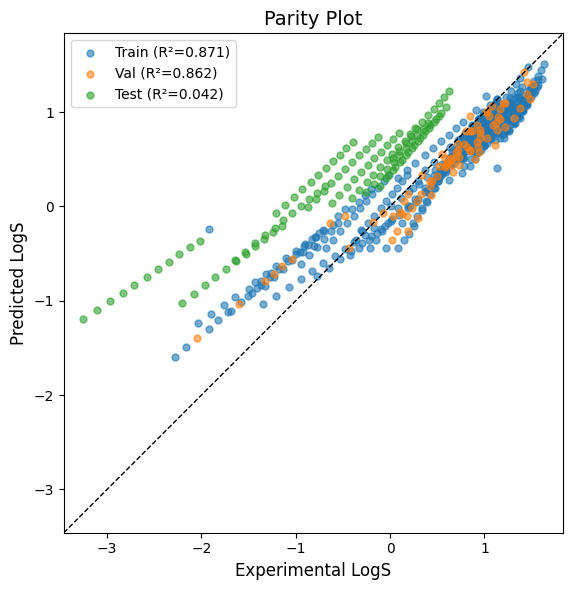

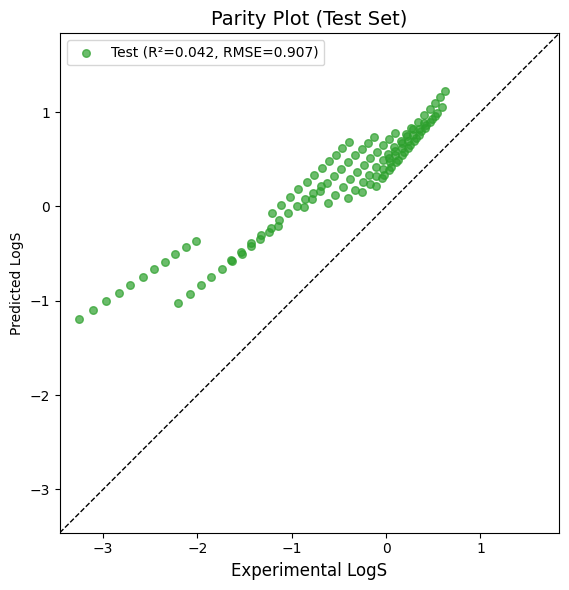


[ChemBERTa (Van't Hoff) - Water + 2-Propanol] Train | R²=0.8713 RMSE=0.2953, MAE=0.2452
[ChemBERTa (Van't Hoff) - Water + 2-Propanol] Val   | R²=0.8615 RMSE=0.2626, MAE=0.2162
[ChemBERTa (Van't Hoff) - Water + 2-Propanol] Test  | R²=0.0416 RMSE=0.9067, MAE=0.8043


In [38]:
# ============================================================================
# Plotting for ChemBERTa (Van't Hoff) — Water + 2-Propanol Solvent Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from rdkit import Chem

# ── Load ChemBERTa (Van't Hoff) solvent split model ────────────────────────
checkpoint_chemberta_solv = torch.load('chemberta_water_prop_model.pt', map_location=DEVICE)

chemberta_model_solv_loaded = FineTunedChemBERTa(**checkpoint_chemberta_solv['model_config']).to(DEVICE)
chemberta_model_solv_loaded.load_state_dict(checkpoint_chemberta_solv['model_state_dict'])
chemberta_model_solv_loaded.eval()

print("Loaded chemberta_water_prop_model — ready for inference/plotting, no training needed.")

# ── Recreate the solvent split indices ──────────────────────────────────────
WATER_SMILES = "O"
ISOPROPANOL_SMILES = "CC(C)O"

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

water_canon = canon(WATER_SMILES)
ipa_canon = canon(ISOPROPANOL_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == water_canon) & (df['_smiles2_canon'] == ipa_canon)) |
    ((df['_smiles1_canon'] == ipa_canon) & (df['_smiles2_canon'] == water_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values
idx_solv_train, idx_solv_val = train_test_split(idx_solv_remain, test_size=0.15, random_state=42)

print(f"Recreated solvent split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

# ── Recreate datasets for ChemBERTa (Van't Hoff) ────────────────────────────
# Note: Van't Hoff ChemBERTa uses the dataset without temperature scaler
chemberta_dataset = SolubilityDataset(df)  # Original dataset without temp scaler

chem_train_dataset_solv = Subset(chemberta_dataset, idx_solv_train)
chem_val_dataset_solv   = Subset(chemberta_dataset, idx_solv_val)
chem_test_dataset_solv  = Subset(chemberta_dataset, idx_solv_test)

chem_train_loader_solv = DataLoader(chem_train_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_val_loader_solv   = DataLoader(chem_val_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_solv  = DataLoader(chem_test_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ── Get ChemBERTa predictions ──────────────────────────────────────────────
chemberta_model_solv_loaded.eval()

# Train predictions
train_preds, train_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv_loaded(smiles1, smiles2, comp1, T_batch)
        train_preds.extend(predictions.squeeze().cpu().numpy())
        train_targets.extend(y.numpy())

# Val predictions
val_preds, val_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_val_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv_loaded(smiles1, smiles2, comp1, T_batch)
        val_preds.extend(predictions.squeeze().cpu().numpy())
        val_targets.extend(y.numpy())

# Test predictions
test_preds, test_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv_loaded(smiles1, smiles2, comp1, T_batch)
        test_preds.extend(predictions.squeeze().cpu().numpy())
        test_targets.extend(y.numpy())

train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets, train_preds)
r2_val,   rmse_val   = get_metrics(val_targets,   val_preds)
r2_test,  rmse_test  = get_metrics(test_targets,  test_preds)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets, val_targets, test_targets])
all_pred = np.concatenate([train_preds, val_preds, test_preds])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets, train_preds, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets,   val_preds,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets,  test_preds,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS', fontsize=12)
plt.title('Parity Plot', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS')
plt.title('Parity Plot (Test Set)', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa (Van't Hoff) - Water + 2-Propanol] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets - train_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Water + 2-Propanol] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets - val_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Water + 2-Propanol] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")


COMPARISON — Solvent-BASED SPLIT (water + 2-propanol held out)
Model       Set             R²      RMSE       MAE
ChemBERTa   Train       0.8713    0.2953    0.2452
ChemBERTa   Test        0.0416    0.9067    0.8043
Mordred     Train       0.9584    0.1679    0.1015
Mordred     Test        0.7715    0.4428    0.3374


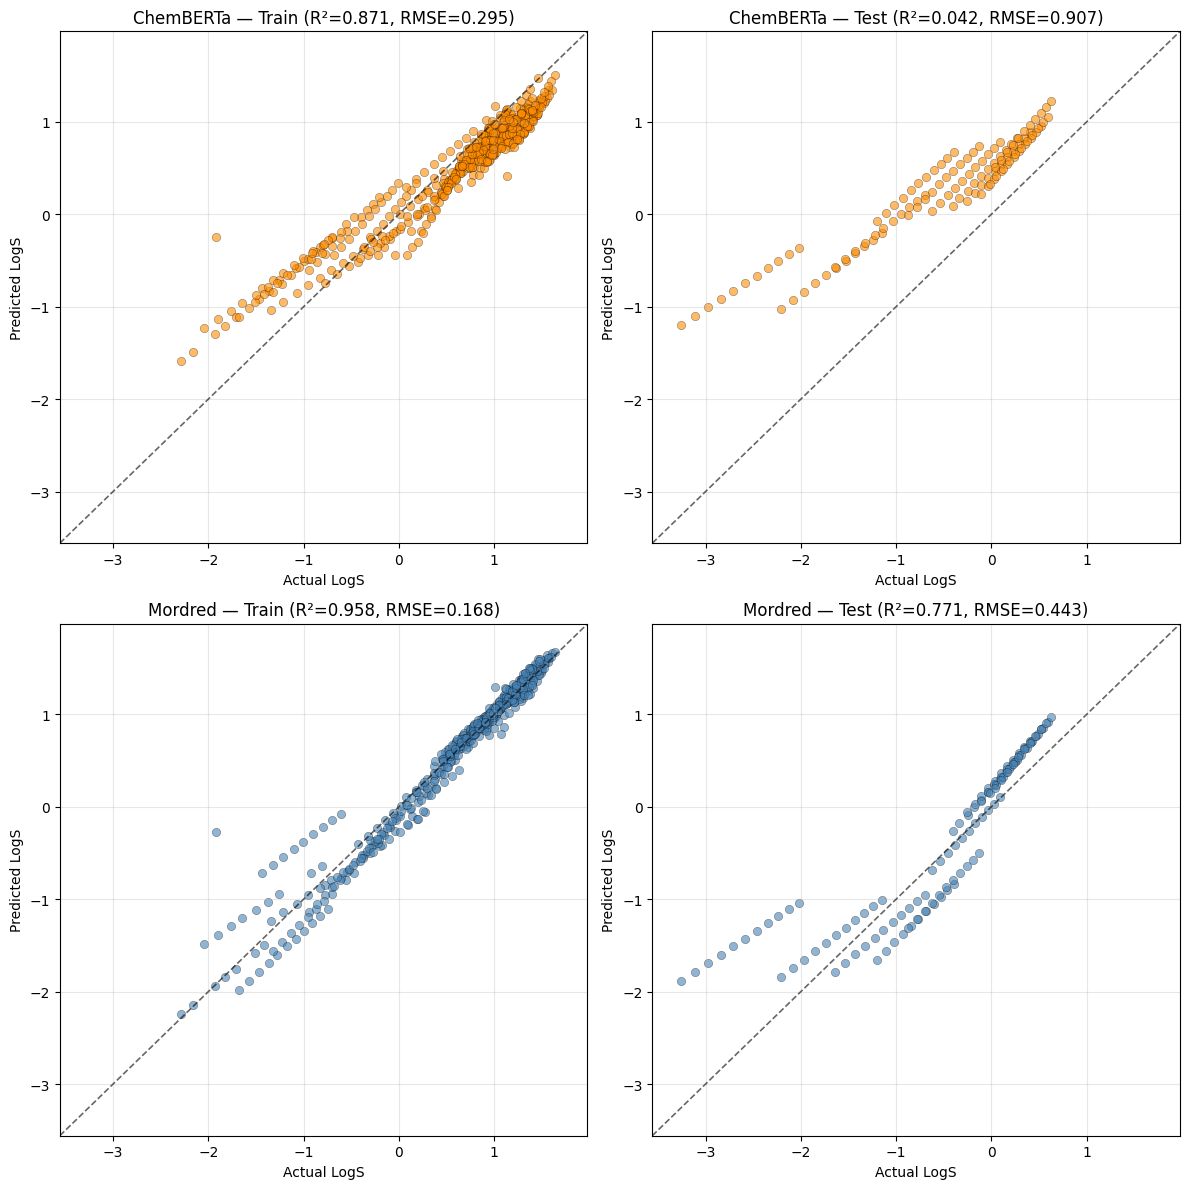

In [55]:
# ============================================================================
# PART 3 (Solvent SPLIT): SIDE-BY-SIDE COMPARISON — 2x2 GRID 
# ============================================================================

print("\n" + "="*60)
print("COMPARISON — Solvent-BASED SPLIT (water + 2-propanol held out)")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c_solv:>10.4f}{rmse_train_c_solv:>10.4f}{mae_train_c_solv:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c_solv:>10.4f}{rmse_c_solv:>10.4f}{mae_c_solv:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m_solv:>10.4f}{rmse_train_m_solv:>10.4f}{mae_train_m_solv:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m_solv:>10.4f}{rmse_test_m_solv:>10.4f}{mae_test_m_solv:>10.4f}")

# ── 2x2 grid: row 0 = ChemBERTa, row 1 = Mordred | col 0 = Train, col 1 = Test ──
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals_solv = np.concatenate([
    train_targets_c_solv, train_preds_c_solv, test_targets_c_solv, test_preds_c_solv,
    Y_train_np_solv, Y_pred_train_mordred_solv, Y_test_np_solv, Y_pred_test_mordred_solv
])
lims_solv = [all_vals_solv.min() - 0.3, all_vals_solv.max() + 0.3]

plot_specs_solv = [
    (0, 0, train_targets_c_solv, train_preds_c_solv, 'darkorange', 'ChemBERTa', 'Train', r2_train_c_solv, rmse_train_c_solv),
    (0, 1, test_targets_c_solv,  test_preds_c_solv,  'darkorange', 'ChemBERTa', 'Test',  r2_c_solv,        rmse_c_solv),
    (1, 0, Y_train_np_solv,      Y_pred_train_mordred_solv, 'steelblue', 'Mordred', 'Train', r2_train_m_solv, rmse_train_m_solv),
    (1, 1, Y_test_np_solv,       Y_pred_test_mordred_solv,  'steelblue', 'Mordred', 'Test',  r2_test_m_solv,  rmse_test_m_solv),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs_solv:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims_solv, lims_solv, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims_solv); ax.set_ylim(lims_solv)
    ax.set_xlabel('Actual LogS')
    ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_solv_split.png', dpi=150)
plt.show()

In [8]:
# ============================================================================
# SOLVENT-PAIR-BASED SPLIT (separate from random & temperature splits — different names)
# Holds out ALL rows where the solvent pair is Toluene + Acetone, for any composition/temperature.
# ============================================================================
from rdkit import Chem

Toluene_SMILES = "C=1C=CC(=CC1)C"
ACETONE_SMILES = "O=C(C)C"
                 
def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

toluene_canon = canon(Toluene_SMILES)
acetone_canon = canon(ACETONE_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == toluene_canon) & (df['_smiles2_canon'] == acetone_canon)) |
    ((df['_smiles1_canon'] == acetone_canon) & (df['_smiles2_canon'] == toluene_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values

print(f"Rows found for Toluene + Acetone pair: {len(idx_solv_test)}")
if len(idx_solv_test) == 0:
    print("WARNING: no rows matched — check that this solvent pair actually exists in the dataset.")
    print("Unique solvent pairs in the dataset:")
    print(df[['SMILES_1', 'SMILES_2']].drop_duplicates().to_string())

# Carve a validation set out of the remaining (non-holdout) rows
idx_solv_train, idx_solv_val = train_test_split(
    idx_solv_remain, test_size=0.15, random_state=42
)

print(f"Solvent-pair split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

# Clean up helper columns (not needed downstream)
df.drop(columns=['_smiles1_canon', '_smiles2_canon'], inplace=True)

# ============================================================================
# STAGE 4: MORDRED MODEL — SOLVENT-PAIR-BASED SPLIT (Toluene + Acetone held out)
# ============================================================================

scaler_fp_solv = StandardScaler().fit(X_fp[idx_solv_train])
scaler_comp_solv = StandardScaler().fit(x1[idx_solv_train])

X_fp_train_solv = scaler_fp_solv.transform(X_fp[idx_solv_train])
X_fp_val_solv   = scaler_fp_solv.transform(X_fp[idx_solv_val])
X_fp_test_solv  = scaler_fp_solv.transform(X_fp[idx_solv_test])

x1_train_solv = scaler_comp_solv.transform(x1[idx_solv_train])
x1_val_solv   = scaler_comp_solv.transform(x1[idx_solv_val])
x1_test_solv  = scaler_comp_solv.transform(x1[idx_solv_test])

T_train_solv, T_val_solv, T_test_solv = T[idx_solv_train], T[idx_solv_val], T[idx_solv_test]
Y_train_solv, Y_val_solv, Y_test_solv = Y[idx_solv_train], Y[idx_solv_val], Y[idx_solv_test]

print(f"[Solvent split/Mordred] Train: {len(X_fp_train_solv)} | Val: {len(X_fp_val_solv)} | Test: {len(X_fp_test_solv)}")

X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t = map(
    to_t, [X_fp_train_solv, x1_train_solv, T_train_solv, Y_train_solv]
)
X_fp_val_solv_t, x1_val_solv_t, T_val_solv_t, Y_val_solv_t = map(
    to_t, [X_fp_val_solv, x1_val_solv, T_val_solv, Y_val_solv]
)
X_fp_test_solv_t, x1_test_solv_t, T_test_solv_t, Y_test_solv_t = map(
    to_t, [X_fp_test_solv, x1_test_solv, T_test_solv, Y_test_solv]
)

train_ds_solv = TensorDataset(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t)
val_ds_solv   = TensorDataset(X_fp_val_solv_t,   x1_val_solv_t,   T_val_solv_t,   Y_val_solv_t)
test_ds_solv  = TensorDataset(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t,  Y_test_solv_t)

train_loader_solv = DataLoader(train_ds_solv, batch_size=32, shuffle=True)
val_loader_solv   = DataLoader(val_ds_solv,   batch_size=len(val_ds_solv),  shuffle=False)
test_loader_solv  = DataLoader(test_ds_solv,  batch_size=len(test_ds_solv), shuffle=False)

mordred_model_solv = SolubilityHybridModelV2(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    physpar_hidden_layers=[32], physpar_dropout=0.1, physpar_actfunc='Tanh',
    A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0,
)
print(f"[Solvent split/Mordred] Total trainable parameters: {mordred_model_solv.count_parameters()}")

optimizer_solv = torch.optim.Adam(mordred_model_solv.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_solv, patience_counter_solv, best_weights_solv = float('inf'), 0, None
train_losses_solv, val_losses_solv = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_solv.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_solv:
        optimizer_solv.zero_grad()
        Y_pred = mordred_model_solv(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_solv.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_solv)

    mordred_model_solv.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_solv:
            epoch_val_loss = criterion(mordred_model_solv(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_solv.append(epoch_train_loss)
    val_losses_solv.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_solv:
        best_val_loss_solv = epoch_val_loss
        best_weights_solv = {k: v.clone() for k, v in mordred_model_solv.state_dict().items()}
        patience_counter_solv = 0
    else:
        patience_counter_solv += 1
        if patience_counter_solv >= PATIENCE:
            print(f"[Solvent split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Solvent split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_solv.load_state_dict(best_weights_solv)
print(f"\n[Solvent split/Mordred] Best val loss: {best_val_loss_solv:.4f}")

mordred_model_solv.eval()
with torch.no_grad():
    Y_pred_train_mordred_solv = mordred_model_solv(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t).numpy().flatten()
    Y_pred_test_mordred_solv  = mordred_model_solv(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t).numpy().flatten()

Y_train_np_solv = Y_train_solv_t.numpy().flatten()
Y_test_np_solv  = Y_test_solv_t.numpy().flatten()

r2_train_m_solv, rmse_train_m_solv, mae_train_m_solv = get_metrics(Y_train_np_solv, Y_pred_train_mordred_solv)
r2_test_m_solv,  rmse_test_m_solv,  mae_test_m_solv  = get_metrics(Y_test_np_solv,  Y_pred_test_mordred_solv)

print(f"[Solvent split/Mordred] Train | R²={r2_train_m_solv:.4f} RMSE={rmse_train_m_solv:.4f} MAE={mae_train_m_solv:.4f}")
print(f"[Solvent split/Mordred] Test  | R²={r2_test_m_solv:.4f} RMSE={rmse_test_m_solv:.4f} MAE={mae_test_m_solv:.4f}")

Rows found for Toluene + Acetone pair: 63
Solvent-pair split -> Train: 527 | Val: 94 | Test: 63
[Solvent split/Mordred] Train: 527 | Val: 94 | Test: 63
[Solvent split/Mordred] Total trainable parameters: 873570
[Solvent split/Mordred] Epoch   50 | Train: 0.2425 | Val: 0.0661
[Solvent split/Mordred] Epoch  100 | Train: 0.1471 | Val: 0.0406
[Solvent split/Mordred] Epoch  150 | Train: 0.1299 | Val: 0.0204
[Solvent split/Mordred] Epoch  200 | Train: 0.1290 | Val: 0.0161
[Solvent split/Mordred] Epoch  250 | Train: 0.0991 | Val: 0.0144
[Solvent split/Mordred] Epoch  300 | Train: 0.0970 | Val: 0.0090
[Solvent split/Mordred] Epoch  350 | Train: 0.0929 | Val: 0.0165
[Solvent split/Mordred] Epoch  400 | Train: 0.1027 | Val: 0.0127
[Solvent split/Mordred] Epoch  450 | Train: 0.0955 | Val: 0.0083
[Solvent split/Mordred] Early stopping at epoch 454

[Solvent split/Mordred] Best val loss: 0.0054
[Solvent split/Mordred] Train | R²=0.9916 RMSE=0.0868 MAE=0.0584
[Solvent split/Mordred] Test  | R²=-1.19

In [57]:
# ── Save model weights + scalers + architecture config together ────────────
torch.save({
    'model_state_dict': mordred_model_solv.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'physpar_hidden_layers': [32], 'physpar_dropout': 0.1, 'physpar_actfunc': 'Tanh',
        'A_min': 2.5, 'A_max': 6.5, 'B_min': -2500.0, 'B_max': -500.0,
    }
}, 'mordred_toluene_acetone_split_model.pt')

with open('mordred_toluene_acetone_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_solv, 'scaler_comp': scaler_comp_solv}, f)

print("Saved model to 'mordred_toluene_acetone_split_model.pt' and scalers to 'mordred_toluene_acetone_split_scalers.pkl'")


Saved model to 'mordred_toluene_acetone_split_model.pt' and scalers to 'mordred_toluene_acetone_split_scalers.pkl'


In [58]:
# ============================================================================
# Load the model and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load model + scalers (no training required) ─────────────────────────────
checkpoint_solv = torch.load('mordred_toluene_acetone_split_model.pt')

mordred_model_toluene_acetone_loaded = SolubilityHybridModelV2(**checkpoint_solv['model_config'])
mordred_model_toluene_acetone_loaded.load_state_dict(checkpoint_solv['model_state_dict'])
mordred_model_toluene_acetone_loaded.eval()

with open('mordred_toluene_acetone_split_scalers.pkl', 'rb') as f:
    scalers_solv = pickle.load(f)
scaler_fp_toluene_acetone_loaded = scalers_solv['scaler_fp']
scaler_comp_toluene_acetone_loaded = scalers_solv['scaler_comp']

print("Loaded mordred_toluene_acetone_split_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_toluene_acetone_split_model and scalers — ready for inference/plotting, no training needed.


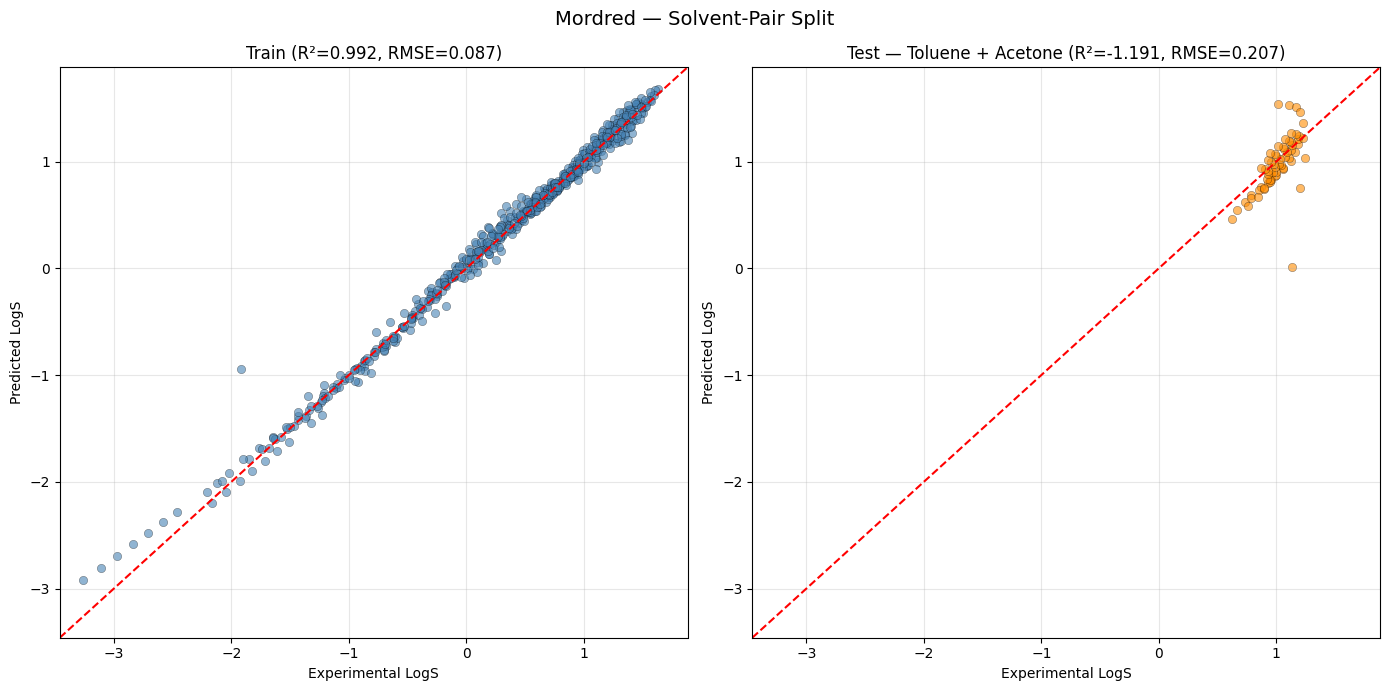

In [9]:
# ============================================================================
# PARITY PLOT — Mordred, Solvent-Pair Split (Toluene + Acetone held out)
# Train and Test side by side, 1 row x 2 subplots
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

all_vals_solv = np.concatenate([Y_train_np_solv, Y_pred_train_mordred_solv,
                                 Y_test_np_solv, Y_pred_test_mordred_solv])
lims_solv = [all_vals_solv.min() - 0.2, all_vals_solv.max() + 0.2]

axes[0].scatter(Y_train_np_solv, Y_pred_train_mordred_solv, alpha=0.6,
                color='steelblue', edgecolors='k', linewidths=0.3)
axes[0].plot(lims_solv, lims_solv, 'r--', lw=1.5)
axes[0].set_xlim(lims_solv); axes[0].set_ylim(lims_solv)
axes[0].set_xlabel('Experimental LogS'); axes[0].set_ylabel('Predicted LogS')
axes[0].set_title(f'Train (R²={r2_train_m_solv:.3f}, RMSE={rmse_train_m_solv:.3f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(Y_test_np_solv, Y_pred_test_mordred_solv, alpha=0.6,
                color='darkorange', edgecolors='k', linewidths=0.3)
axes[1].plot(lims_solv, lims_solv, 'r--', lw=1.5)
axes[1].set_xlim(lims_solv); axes[1].set_ylim(lims_solv)
axes[1].set_xlabel('Experimental LogS'); axes[1].set_ylabel('Predicted LogS')
axes[1].set_title(f'Test — Toluene + Acetone (R²={r2_test_m_solv:.3f}, RMSE={rmse_test_m_solv:.3f})')
axes[1].grid(alpha=0.3)

fig.suptitle('Mordred — Solvent-Pair Split', fontsize=14)
plt.tight_layout()
plt.savefig('mordred_solv_split_parity.png', dpi=150)
plt.show()

Rows found for held-out solvent pairs: 126
  C=1C=CC(=CC1)C + O=C(C)C: 63 rows
  C=1C=CC(=CC1)C + O1CCCC1: 63 rows

Solvent-pair split -> Train: 474 | Val: 84 | Test: 126
[Solvent split/Mordred] Train: 474 | Val: 84 | Test: 126
[Solvent split/Mordred] Total trainable parameters: 873570
[Solvent split/Mordred] Epoch   50 | Train: 0.2078 | Val: 0.0840
[Solvent split/Mordred] Epoch  100 | Train: 0.1436 | Val: 0.0554
[Solvent split/Mordred] Epoch  150 | Train: 0.1235 | Val: 0.0257
[Solvent split/Mordred] Epoch  200 | Train: 0.1169 | Val: 0.0201
[Solvent split/Mordred] Epoch  250 | Train: 0.1051 | Val: 0.0194
[Solvent split/Mordred] Epoch  300 | Train: 0.0981 | Val: 0.0137
[Solvent split/Mordred] Epoch  350 | Train: 0.1044 | Val: 0.0132
[Solvent split/Mordred] Epoch  400 | Train: 0.0855 | Val: 0.0162
[Solvent split/Mordred] Early stopping at epoch 403

[Solvent split/Mordred] Best val loss: 0.0095
[Solvent split/Mordred] Train | R²=0.9889 RMSE=0.0985 MAE=0.0747
[Solvent split/Mordred] Test 

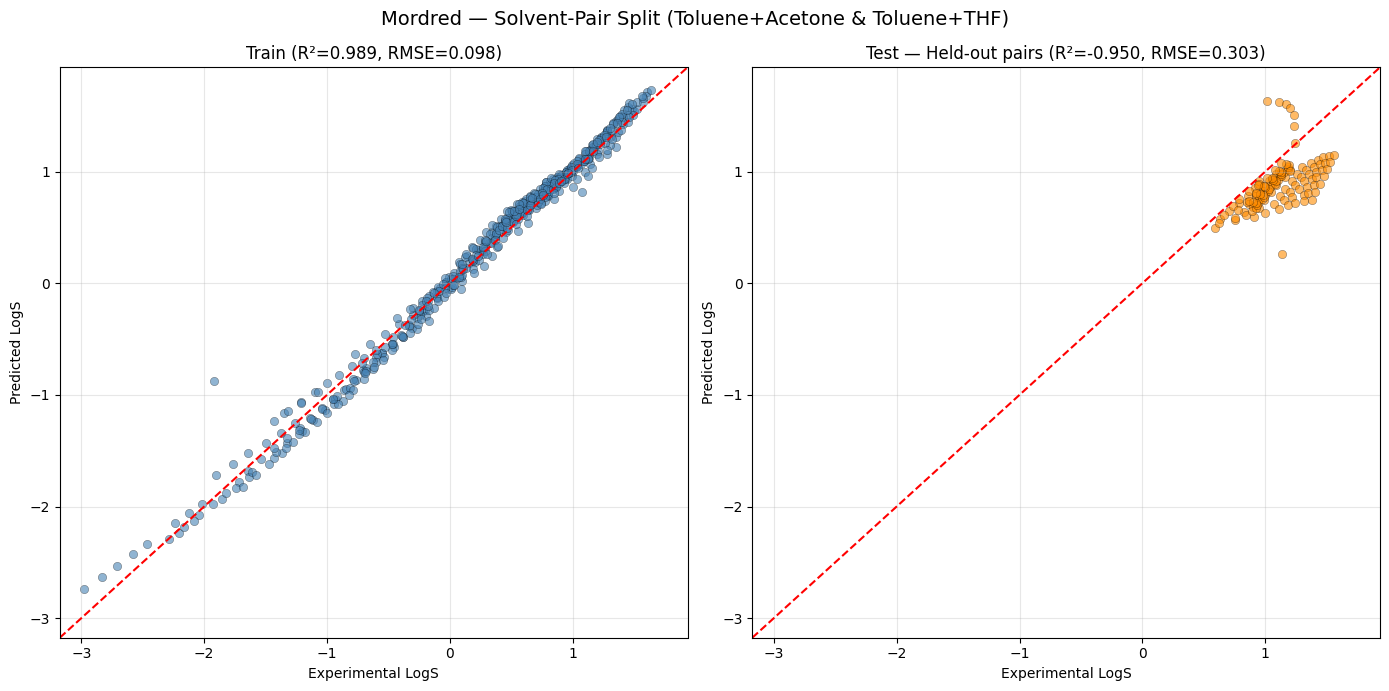

In [10]:
# ============================================================================
# SOLVENT-PAIR-BASED SPLIT (separate from random & temperature splits — different names)
# Holds out ALL rows matching ANY of the specified solvent pairs, for any composition/temperature.
# ============================================================================
from rdkit import Chem

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

# ── List of solvent pairs to hold out for test (add more tuples as needed) ──
HOLDOUT_PAIRS_SMILES = [
    ("C=1C=CC(=CC1)C", "O=C(C)C"),   # Toluene + Acetone
    ("C=1C=CC(=CC1)C", "O1CCCC1"),   # Toluene + Tetrahydrofuran
]

holdout_pairs_canon = [
    frozenset([canon(smi_a), canon(smi_b)]) for smi_a, smi_b in HOLDOUT_PAIRS_SMILES
]

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

df['_pair_canon'] = df.apply(
    lambda r: frozenset([r['_smiles1_canon'], r['_smiles2_canon']]), axis=1
)

mask_solv_test = df['_pair_canon'].isin(holdout_pairs_canon)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values

print(f"Rows found for held-out solvent pairs: {len(idx_solv_test)}")
if len(idx_solv_test) == 0:
    print("WARNING: no rows matched — check that these solvent pairs actually exist in the dataset.")
    print("Unique solvent pairs in the dataset:")
    print(df[['SMILES_1', 'SMILES_2']].drop_duplicates().to_string())
else:
    for smi_a, smi_b in HOLDOUT_PAIRS_SMILES:
        pair_canon = frozenset([canon(smi_a), canon(smi_b)])
        n_rows = (df['_pair_canon'] == pair_canon).sum()
        print(f"  {smi_a} + {smi_b}: {n_rows} rows")

# Carve a validation set out of the remaining (non-holdout) rows
idx_solv_train, idx_solv_val = train_test_split(
    idx_solv_remain, test_size=0.15, random_state=42
)

print(f"\nSolvent-pair split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

df.drop(columns=['_smiles1_canon', '_smiles2_canon', '_pair_canon'], inplace=True)


# ============================================================================
# STAGE 4: MORDRED MODEL — SOLVENT-PAIR-BASED SPLIT (multiple pairs held out)
# ============================================================================
scaler_fp_solv = StandardScaler().fit(X_fp[idx_solv_train])
scaler_comp_solv = StandardScaler().fit(x1[idx_solv_train])

X_fp_train_solv = scaler_fp_solv.transform(X_fp[idx_solv_train])
X_fp_val_solv   = scaler_fp_solv.transform(X_fp[idx_solv_val])
X_fp_test_solv  = scaler_fp_solv.transform(X_fp[idx_solv_test])

x1_train_solv = scaler_comp_solv.transform(x1[idx_solv_train])
x1_val_solv   = scaler_comp_solv.transform(x1[idx_solv_val])
x1_test_solv  = scaler_comp_solv.transform(x1[idx_solv_test])

T_train_solv, T_val_solv, T_test_solv = T[idx_solv_train], T[idx_solv_val], T[idx_solv_test]
Y_train_solv, Y_val_solv, Y_test_solv = Y[idx_solv_train], Y[idx_solv_val], Y[idx_solv_test]

print(f"[Solvent split/Mordred] Train: {len(X_fp_train_solv)} | Val: {len(X_fp_val_solv)} | Test: {len(X_fp_test_solv)}")

X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t = map(
    to_t, [X_fp_train_solv, x1_train_solv, T_train_solv, Y_train_solv]
)
X_fp_val_solv_t, x1_val_solv_t, T_val_solv_t, Y_val_solv_t = map(
    to_t, [X_fp_val_solv, x1_val_solv, T_val_solv, Y_val_solv]
)
X_fp_test_solv_t, x1_test_solv_t, T_test_solv_t, Y_test_solv_t = map(
    to_t, [X_fp_test_solv, x1_test_solv, T_test_solv, Y_test_solv]
)

train_ds_solv = TensorDataset(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t)
val_ds_solv   = TensorDataset(X_fp_val_solv_t,   x1_val_solv_t,   T_val_solv_t,   Y_val_solv_t)
test_ds_solv  = TensorDataset(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t,  Y_test_solv_t)

train_loader_solv = DataLoader(train_ds_solv, batch_size=32, shuffle=True)
val_loader_solv   = DataLoader(val_ds_solv,   batch_size=len(val_ds_solv),  shuffle=False)
test_loader_solv  = DataLoader(test_ds_solv,  batch_size=len(test_ds_solv), shuffle=False)

mordred_model_solv = SolubilityHybridModelV2(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    physpar_hidden_layers=[32], physpar_dropout=0.1, physpar_actfunc='Tanh',
    A_min=2.5, A_max=6.5, B_min=-2500.0, B_max=-500.0,
)
print(f"[Solvent split/Mordred] Total trainable parameters: {mordred_model_solv.count_parameters()}")

optimizer_solv = torch.optim.Adam(mordred_model_solv.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_solv, patience_counter_solv, best_weights_solv = float('inf'), 0, None
train_losses_solv, val_losses_solv = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_solv.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_solv:
        optimizer_solv.zero_grad()
        Y_pred = mordred_model_solv(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_solv.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_solv)

    mordred_model_solv.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_solv:
            epoch_val_loss = criterion(mordred_model_solv(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_solv.append(epoch_train_loss)
    val_losses_solv.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_solv:
        best_val_loss_solv = epoch_val_loss
        best_weights_solv = {k: v.clone() for k, v in mordred_model_solv.state_dict().items()}
        patience_counter_solv = 0
    else:
        patience_counter_solv += 1
        if patience_counter_solv >= PATIENCE:
            print(f"[Solvent split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Solvent split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_solv.load_state_dict(best_weights_solv)
print(f"\n[Solvent split/Mordred] Best val loss: {best_val_loss_solv:.4f}")

mordred_model_solv.eval()
with torch.no_grad():
    Y_pred_train_mordred_solv = mordred_model_solv(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t).numpy().flatten()
    Y_pred_test_mordred_solv  = mordred_model_solv(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t).numpy().flatten()

Y_train_np_solv = Y_train_solv_t.numpy().flatten()
Y_test_np_solv  = Y_test_solv_t.numpy().flatten()

r2_train_m_solv, rmse_train_m_solv, mae_train_m_solv = get_metrics(Y_train_np_solv, Y_pred_train_mordred_solv)
r2_test_m_solv,  rmse_test_m_solv,  mae_test_m_solv  = get_metrics(Y_test_np_solv,  Y_pred_test_mordred_solv)

print(f"[Solvent split/Mordred] Train | R²={r2_train_m_solv:.4f} RMSE={rmse_train_m_solv:.4f} MAE={mae_train_m_solv:.4f}")
print(f"[Solvent split/Mordred] Test  | R²={r2_test_m_solv:.4f} RMSE={rmse_test_m_solv:.4f} MAE={mae_test_m_solv:.4f}")


# ============================================================================
# PARITY PLOT — Mordred, Solvent-Pair Split (Toluene+Acetone & Toluene+THF held out)
# Train and Test side by side, 1 row x 2 subplots
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

all_vals_solv = np.concatenate([Y_train_np_solv, Y_pred_train_mordred_solv,
                                 Y_test_np_solv, Y_pred_test_mordred_solv])
lims_solv = [all_vals_solv.min() - 0.2, all_vals_solv.max() + 0.2]

axes[0].scatter(Y_train_np_solv, Y_pred_train_mordred_solv, alpha=0.6,
                color='steelblue', edgecolors='k', linewidths=0.3)
axes[0].plot(lims_solv, lims_solv, 'r--', lw=1.5)
axes[0].set_xlim(lims_solv); axes[0].set_ylim(lims_solv)
axes[0].set_xlabel('Experimental LogS'); axes[0].set_ylabel('Predicted LogS')
axes[0].set_title(f'Train (R²={r2_train_m_solv:.3f}, RMSE={rmse_train_m_solv:.3f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(Y_test_np_solv, Y_pred_test_mordred_solv, alpha=0.6,
                color='darkorange', edgecolors='k', linewidths=0.3)
axes[1].plot(lims_solv, lims_solv, 'r--', lw=1.5)
axes[1].set_xlim(lims_solv); axes[1].set_ylim(lims_solv)
axes[1].set_xlabel('Experimental LogS'); axes[1].set_ylabel('Predicted LogS')
axes[1].set_title(f'Test — Held-out pairs (R²={r2_test_m_solv:.3f}, RMSE={rmse_test_m_solv:.3f})')
axes[1].grid(alpha=0.3)

fig.suptitle('Mordred — Solvent-Pair Split (Toluene+Acetone & Toluene+THF)', fontsize=14)
plt.tight_layout()
plt.savefig('mordred_solv_split_parity.png', dpi=150)
plt.show()